In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("Ingresa el tiempo desde el que quieres bajar los datos(ej: 5d, 3wk, 3mo, 5y, max): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Temporalidad de los datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE

# ============================================
# 1. DESCARGA Y PREPARACIÓN DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER}...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CREAR DATAFRAME SOLO CON CLOSE (para forecast)
# ============================================
print("\n" + "=" * 70)
print("2. PREPARANDO DATOS...")
print("=" * 70)

# Crear DataFrame solo con Close (como en el código original)
apple = pd.DataFrame(df['Close'])
apple.columns = ['Close']

print(f"✓ DataFrame creado: {apple.shape[0]} filas")

# ============================================
# 3. CREAR TARGET DE PRECIO
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGET...")
print("=" * 70)

apple["Prediction"] = apple[["Close"]].shift(-DIAS_HORIZONTE)

print(f"✓ Target creado: shift(-{DIAS_HORIZONTE})")
print(f"  Últimas {DIAS_HORIZONTE} filas tienen NaN")

# ============================================
# 4. PREPARAR X e Y PARA PRECIO (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print("4. PREPARANDO X e Y...")
print("=" * 70)

# X = todas las filas excepto las últimas DIAS_HORIZONTE
X = np.array(apple.drop(columns=["Prediction"]))[:-DIAS_HORIZONTE]
Y = np.array(apple["Prediction"])[:-DIAS_HORIZONTE]

print(f"✓ X shape: {X.shape}")
print(f"✓ Y shape: {Y.shape}")

# ============================================
# 5. ENTRENAR ÁRBOL DE DECISIONES (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print("5. ENTRENANDO ÁRBOL DE DECISIONES...")
print("=" * 70)

modelo_precio = DecisionTreeRegressor(random_state=SEED)
modelo_precio.fit(X, Y)

print("✓ Árbol de Decisión entrenado")

# ============================================
# 6. PREDECIR LOS PRÓXIMOS DIAS_HORIZONTE DÍAS
# ============================================
print("\n" + "=" * 70)
print("6. PREDICIENDO...")
print("=" * 70)

# Tomar los últimos DIAS_HORIZONTE días como base
xfuture = apple.drop(columns=["Prediction"])[:-DIAS_HORIZONTE]
xfuture = xfuture.tail(DIAS_HORIZONTE)
xfuture = np.array(xfuture)

precios_futuros = modelo_precio.predict(xfuture)

print(f"✓ Predicciones generadas para {len(precios_futuros)} días")

# ============================================
# 7. CREAR DATAFRAME DE VALIDACIÓN (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print("7. PREPARANDO VALIDACIÓN...")
print("=" * 70)

valid = apple.iloc[X.shape[0]:].copy()
valid.loc[:, "Predictions"] = precios_futuros

print(f"✓ Período de validación: {valid.index[0].date()} a {valid.index[-1].date()}")
print(f"✓ Días a validar: {len(valid)}")

# ============================================
# 8. MÉTRICAS DE PRECIO
# ============================================
print("\n" + "=" * 70)
print("8. MÉTRICAS")
print("=" * 70)

mae = mean_absolute_error(valid["Close"], valid["Predictions"])
rmse = np.sqrt(mean_squared_error(valid["Close"], valid["Predictions"]))
r2 = r2_score(valid["Close"], valid["Predictions"])
errors_pct = ((valid["Predictions"] - valid["Close"]) / valid["Close"]) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 PRECIO (DecisionTreeRegressor):")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO (CON PLOTLY)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=apple.index, y=apple['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)',
    hovertemplate='<b>📅 Fecha:</b> %{x}<br><b>💰 Precio:</b> $%{y:.2f}<extra></extra>'
))

ma50 = apple['Close'].rolling(50).mean()
ma200 = apple['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=apple.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=apple.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

precio_max, precio_min = apple['Close'].max(), apple['Close'].min()
fecha_max, fecha_min = apple['Close'].idxmax(), apple['Close'].idxmin()

fig_historico.add_trace(go.Scatter(x=[fecha_max], y=[precio_max], mode='markers+text',
                                   name=f'Máximo: ${precio_max:.2f}',
                                   marker=dict(color='green', size=12, symbol='star'),
                                   text=[f' ${precio_max:.2f}'], textposition='top center'))
fig_historico.add_trace(go.Scatter(x=[fecha_min], y=[precio_min], mode='markers+text',
                                   name=f'Mínimo: ${precio_min:.2f}',
                                   marker=dict(color='red', size=10),
                                   text=[f' ${precio_min:.2f}'], textposition='bottom center'))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b><br><sub>{apple.index[0].date()} a {apple.index[-1].date()}</sub>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), rangeselector=dict(
        buttons=[dict(count=1, label="1y", step="year", stepmode="backward"),
                 dict(step="all", label="Todo")]))
)
fig_historico.show()

# ============================================
# GRÁFICA 2: COMPARACIÓN REAL vs PREDICCIÓN (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio")
print("=" * 70)

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])

# Precio real
fig_precio.add_trace(go.Scatter(
    x=valid.index, y=valid['Close'],
    mode='lines+markers', name='Precio Real',
    line=dict(color='green', width=2.5), marker=dict(size=4)
), row=1, col=1)

# Predicción
fig_precio.add_trace(go.Scatter(
    x=valid.index, y=valid['Predictions'],
    mode='lines+markers', name='Predicción',
    line=dict(color='red', width=2, dash='dash'), marker=dict(size=4)
), row=1, col=1)

# Área de error
fig_precio.add_trace(go.Scatter(
    x=valid.index.tolist() + valid.index.tolist()[::-1],
    y=valid['Close'].tolist() + valid['Predictions'].tolist()[::-1],
    fill='toself', fillcolor='rgba(128, 0, 128, 0.2)',
    line=dict(color='rgba(0,0,0,0)'), name='Error', hoverinfo='skip'
), row=1, col=1)

# Errores porcentuales
errors_pct_plot = ((valid['Predictions'] - valid['Close']) / valid['Close']) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(
    x=valid.index, y=errors_pct_plot, name='Error %',
    marker_color=colors, opacity=0.6
), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.update_xaxes(title_text="Fecha", row=2, col=1)
fig_precio.update_yaxes(title_text="Precio ($)", row=1, col=1)
fig_precio.update_yaxes(title_text="Error (%)", row=2, col=1)
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: COMPARACIÓN SIMPLE (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 3: {TICKER} - Comparación Real vs Predicción")
print("=" * 70)

plt.figure(figsize=(14, 6))

# Graficar como en tu código original
plt.plot(valid.index, valid['Close'], 
         label='Real', color='blue', linewidth=2.5, marker='o', markersize=4)
plt.plot(valid.index, valid['Predictions'], 
         label='Predicción', color='red', linewidth=2.5, linestyle='--', marker='s', markersize=4)

# Barras de error
for i in range(len(valid)):
    plt.plot([valid.index[i], valid.index[i]], 
             [valid['Close'].iloc[i], valid['Predictions'].iloc[i]], 
             'gray', alpha=0.2, linewidth=1)

plt.title(f'{TICKER} - Predicción con Árbol de Decisión ({len(valid)} días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio de Cierre (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Añadir métricas
metrics_text = f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%'
plt.text(0.02, 0.98, metrics_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 4: RESUMEN ESTADÍSTICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 4: {TICKER} - Resumen Estadístico")
print("=" * 70)

errors_abs = valid['Predictions'] - valid['Close']

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

axes4[0, 0].hist(errors_abs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors_abs.mean(), color='red', linestyle='--', label=f'Media: ${errors_abs.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

axes4[0, 1].scatter(valid['Close'], valid['Predictions'], alpha=0.6, edgecolors='black', linewidth=0.5)
max_val = max(valid['Close'].max(), valid['Predictions'].max())
min_val = min(valid['Close'].min(), valid['Predictions'].min())
axes4[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Predicción Perfecta')
axes4[0, 1].set_title('Real vs Predicho')
axes4[0, 1].set_xlabel('Real ($)')
axes4[0, 1].set_ylabel('Predicho ($)')
axes4[0, 1].legend()
axes4[0, 1].grid(True, alpha=0.3)

metrics_data = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
bars_metrics = axes4[1, 0].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 0].set_xticks(range(len(metrics_data)))
axes4[1, 0].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 0].set_title('Métricas')
axes4[1, 0].set_ylabel('Valor')

for bar, value in zip(bars_metrics, metrics_data.values()):
    axes4[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
axes4[1, 0].grid(True, alpha=0.3, axis='y')

axes4[1, 1].axis('off')

plt.suptitle(f'{TICKER} - Análisis Estadístico ({DIAS_HORIZONTE} días)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# 9. PREDICCIÓN FUTURA (COMO EN EL CÓDIGO ORIGINAL)
# ============================================
print("\n" + "=" * 70)
print(f"PREDICCIÓN FUTURA PARA {TICKER}")
print("=" * 70)

ultima_fecha = apple.index[-1]
precio_actual = apple['Close'].iloc[-1]

print(f"📊 Último dato real: {ultima_fecha.date()} - Precio: ${precio_actual:.2f}")
print(f"🔮 Predicción a {DIAS_HORIZONTE} días...")

# Generar predicciones futuras (como en el código original)
xfuture_futuro = apple.drop(columns=["Prediction"])[:-DIAS_HORIZONTE]
xfuture_futuro = xfuture_futuro.tail(DIAS_HORIZONTE)
xfuture_futuro = np.array(xfuture_futuro)

precios_futuros_final = modelo_precio.predict(xfuture_futuro)

# Derivar señal futura
cambio_futuro = (precios_futuros_final - precio_actual) / precio_actual
senal_futura = (cambio_futuro > UMBRAL_SUBIDA).astype(int)
prob_futura = np.clip(cambio_futuro / (UMBRAL_SUBIDA * 2), 0, 1)

# Fechas futuras
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros_final))]

# Tomar primeros DIAS_A_MOSTRAR días
fechas_mostrar = fechas_futuras[:DIAS_A_MOSTRAR]
precios_mostrar = precios_futuros_final[:DIAS_A_MOSTRAR]
senal_mostrar = senal_futura[:DIAS_A_MOSTRAR]
prob_mostrar = prob_futura[:DIAS_A_MOSTRAR]

cambio_final = ((precios_mostrar[-1] - precio_actual) / precio_actual) * 100

print(f"✅ Predicción generada:")
print(f"   • Período: {fechas_mostrar[0].date()} a {fechas_mostrar[-1].date()}")
print(f"   • Precio final esperado: ${precios_mostrar[-1]:.2f}")
print(f"   • Cambio esperado: {cambio_final:+.2f}%")
print(f"   • Señal: {'🟢 COMPRAR' if senal_mostrar[-1] == 1 else '⚪ MANTENER'}")
print(f"   • Confianza: {prob_mostrar[-1]*100:.1f}%")

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 5: {TICKER} - Predicción Futura")
print("=" * 70)

fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=apple.index[-100:], y=apple['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_mostrar, y=precios_mostrar, mode='lines+markers',
                             name=f'🔮 Predicción {DIAS_HORIZONTE} días',
                             line=dict(color='red', width=2), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'{TICKER} - Predicción Futura a {DIAS_HORIZONTE} días',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()

# ============================================
# TABLA DE PREDICCIONES
# ============================================
print("\n" + "=" * 70)
print(f"📋 TABLA DE PREDICCIONES - PRÓXIMOS {DIAS_HORIZONTE} DÍAS")
print("=" * 70)
print(f"{'Fecha':<15} {'Precio':<12} {'Cambio %':<12} {'Señal':<15} {'Confianza':<12}")
print("-" * 70)

for i in range(len(fechas_mostrar)):
    cambio = ((precios_mostrar[i] - precio_actual) / precio_actual) * 100
    senal_texto = "🟢 COMPRAR" if senal_mostrar[i] == 1 else "⚪ MANTENER"
    print(f"{fechas_mostrar[i].date():<15} ${precios_mostrar[i]:<11.2f} {cambio:+11.2f}% {senal_texto:<15} {prob_mostrar[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {apple.index[0].date()} a {apple.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 MODELO DE PRECIO (DecisionTreeRegressor):")
print(f"  • Error promedio (MAE): ${mae:.2f}")
print(f"  • Raíz del error cuadrático (RMSE): ${rmse:.2f}")
print(f"  • Precisión del modelo (R²): {r2:.4f}")
print(f"  • Error porcentual (MAPE): {mape:.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_mostrar[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")
print(f"  • Señal: {'🟢 COMPRAR' if senal_mostrar[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {prob_mostrar[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("   Las decisiones de inversión deben tomarse con criterio propio.")
print("=" * 70)


plt.ioff()
plt.show(block=True)

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE

# ============================================
# FEATURES PARA CLASIFICADOR (SEÑAL)
# ============================================
FEATURES_CLASIFICADOR = ['Open', 'High', 'Low','Close', 'Volume', 'SD20', 'Upper_Band', 'Lower_Band',
    'S_Close(t-1)', 'S_Close(t-2)', 'S_Close(t-3)', 'S_Close(t-5)', 'S_Open(t-1)',
    'MA5', 'MA10', 'MA20', 'MA50', 'MA200', 'EMA10', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
    'MACD', 'MACD_EMA', 'ATR', 'ADX', 'CCI', 'ROC', 'RSI', 'William%R', 'SO%K', 'STD5',
    'ForceIndex1', 'ForceIndex20', 'Day', 'DayofWeek', 'DayofYear', 'Week',
    'Is_month_end', 'Is_month_start', 'Is_quarter_end', 'Is_quarter_start',
    'Is_year_end', 'Is_year_start', 'Is_leap_year', 'Year', 'Month',
    'QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50',
    'SnP_Close', 'SnP(t-1))', 'SnP(t-5)', 'DJIA_Close', 'DJIA(t-1))', 'DJIA(t-5)']

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • CLASIFICADOR (señal): {len(FEATURES_CLASIFICADOR)} features")
print(f"   • REGRESOR (forecast): solo Close")
print("=" * 70)

# ============================================
# 1. DESCARGA DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER} (período: {TEMP})...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CALCULAR INDICADORES TÉCNICOS
# ============================================
print("\n" + "=" * 70)
print("2. CALCULANDO INDICADORES TÉCNICOS...")
print("=" * 70)

df_indicadores = pd.DataFrame(index=df.index)
df_indicadores['Close'] = df['Close']
df_indicadores['Volume'] = df['Volume']

# Medias móviles
df_indicadores['MA20'] = df['Close'].rolling(20).mean()
df_indicadores['MA200'] = df['Close'].rolling(200).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_indicadores['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df_indicadores['MACD'] = exp1 - exp2

# Bandas de Bollinger
df_indicadores['Upper_Band'] = df['Close'].rolling(20).mean() + (df['Close'].rolling(20).std() * 2)
df_indicadores['Lower_Band'] = df['Close'].rolling(20).mean() - (df['Close'].rolling(20).std() * 2)

# ATR
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_indicadores['ATR'] = tr.rolling(14).mean()

# Precio anterior
df_indicadores['S_Close(t-1)'] = df['Close'].shift(1)
df_indicadores['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

# Williams %R
period_w = 14
highest_high = df['High'].rolling(window=period_w).max()
lowest_low = df['Low'].rolling(window=period_w).min()
df_indicadores['William%R'] = -100 * ((highest_high - df['Close']) / (highest_high - lowest_low))

# ROC
df_indicadores['ROC'] = df['Close'].pct_change(periods=12) * 100

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_indicadores['QQQ_Close'] = qqq['Close']
    else:
        df_indicadores['QQQ_Close'] = 0
except:
    df_indicadores['QQQ_Close'] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_indicadores['SnP_Close'] = spy['Close']
    else:
        df_indicadores['SnP_Close'] = 0
except:
    df_indicadores['SnP_Close'] = 0

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

df_indicadores['Precio_Futuro'] = df_indicadores['Close'].shift(-DIAS_HORIZONTE)
cambio = (df_indicadores['Precio_Futuro'] - df_indicadores['Close']) / df_indicadores['Close']
df_indicadores['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

df_clean = df_indicadores.dropna(subset=['Precio_Futuro', 'Señal_Subida'])

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# PARTE A: CLASIFICADOR (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print("PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)")
print("=" * 70)

features_disponibles = [f for f in FEATURES_CLASIFICADOR if f in df_clean.columns]
X = df_clean[features_disponibles].values
y = df_clean['Señal_Subida'].values

print(f"✓ Features: {len(features_disponibles)} columnas")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

modelo_senal = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
modelo_senal.fit(X_train, y_train)

y_pred = modelo_senal.predict(X_test)
y_proba = modelo_senal.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# PARTE B: REGRESOR (FORECAST DE PRECIO)
# ============================================
print("\n" + "=" * 70)
print("PARTE B: REGRESOR (FORECAST DE PRECIO)")
print("=" * 70)

apple = pd.DataFrame(df['Close'])
apple.columns = ['Close']
apple["Prediction"] = apple[["Close"]].shift(-DIAS_HORIZONTE)

X_precio = np.array(apple.drop(columns=["Prediction"]))[:-DIAS_HORIZONTE]
Y_precio = np.array(apple["Prediction"])[:-DIAS_HORIZONTE]

Xp_train, Xp_test, Yp_train, Yp_test = train_test_split(X_precio, Y_precio, test_size=0.25, random_state=SEED)

modelo_precio = DecisionTreeRegressor()
modelo_precio.fit(Xp_train, Yp_train)

xfuture = apple.drop(columns=["Prediction"])[:-DIAS_HORIZONTE]
xfuture = xfuture.tail(DIAS_HORIZONTE)
xfuture = np.array(xfuture)
precios_futuros = modelo_precio.predict(xfuture)

valid = apple.iloc[X_precio.shape[0]:].copy()
valid.loc[:, "Predictions"] = precios_futuros

mae = mean_absolute_error(valid["Close"], valid["Predictions"])
rmse = np.sqrt(mean_squared_error(valid["Close"], valid["Predictions"]))
r2 = r2_score(valid["Close"], valid["Predictions"])
errors_pct = ((valid["Predictions"] - valid["Close"]) / valid["Close"]) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=df_clean.index, y=df_clean['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)',
    hovertemplate='<b>📅 Fecha:</b> %{x}<br><b>💰 Precio:</b> $%{y:.2f}<extra></extra>'
))

ma50 = df_clean['Close'].rolling(50).mean()
ma200 = df_clean['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

precio_max, precio_min = df_clean['Close'].max(), df_clean['Close'].min()
fecha_max, fecha_min = df_clean['Close'].idxmax(), df_clean['Close'].idxmin()

fig_historico.add_trace(go.Scatter(x=[fecha_max], y=[precio_max], mode='markers+text',
                                   name=f'Máximo: ${precio_max:.2f}',
                                   marker=dict(color='green', size=12, symbol='star'),
                                   text=[f' ${precio_max:.2f}'], textposition='top center'))
fig_historico.add_trace(go.Scatter(x=[fecha_min], y=[precio_min], mode='markers+text',
                                   name=f'Mínimo: ${precio_min:.2f}',
                                   marker=dict(color='red', size=10),
                                   text=[f' ${precio_min:.2f}'], textposition='bottom center'))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b><br><sub>{df_clean.index[0].date()} a {df_clean.index[-1].date()}</sub>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), rangeselector=dict(
        buttons=[dict(count=1, label="1y", step="year", stepmode="backward"),
                 dict(step="all", label="Todo")]))
)
fig_historico.show()

# ============================================
# GRÁFICA 2: VALIDACIÓN DEL FORECAST (REGRESOR)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio (Forecast)")
print("=" * 70)

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])
fig_precio.add_trace(go.Scatter(x=valid.index, y=valid['Close'], mode='lines+markers',
                                name='Precio Real', line=dict(color='green', width=2.5)), row=1, col=1)
fig_precio.add_trace(go.Scatter(x=valid.index, y=valid['Predictions'], mode='lines+markers',
                                name='Predicción', line=dict(color='red', width=2, dash='dash')), row=1, col=1)

errors_pct_plot = ((valid['Predictions'] - valid['Close']) / valid['Close']) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(x=valid.index, y=errors_pct_plot, name='Error %',
                            marker_color=colors, opacity=0.6), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación Forecast a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.update_xaxes(title_text="Fecha", row=2, col=1)
fig_precio.update_yaxes(title_text="Precio ($)", row=1, col=1)
fig_precio.update_yaxes(title_text="Error (%)", row=2, col=1)
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: ANÁLISIS DE CLASIFICACIÓN (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 3: {TICKER} - Análisis de Clasificación (Señal)")
print("=" * 70)

fechas_test = df_clean.index[-len(X_test):]

fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))

# 1. Precio y señales
ax1 = axes1[0, 0]
ax1.plot(fechas_test, df_clean.loc[fechas_test, 'Close'], color='blue', alpha=0.7, linewidth=1.5, label='Precio')

correct_mask = (y_pred == y_test)
incorrect_mask = (y_pred != y_test)

correct_dates = fechas_test[correct_mask]
incorrect_dates = fechas_test[incorrect_mask]
correct_prices = df_clean.loc[correct_dates, 'Close']
incorrect_prices = df_clean.loc[incorrect_dates, 'Close']

ax1.scatter(correct_dates, correct_prices, color='green', s=40,
           label=f'Correctos ({sum(correct_mask)})', alpha=0.7)
ax1.scatter(incorrect_dates, incorrect_prices, color='red', s=60,
           label=f'Incorrectos ({sum(incorrect_mask)})', alpha=0.7)

ax1.set_title(f'{TICKER} - Clasificación (Accuracy: {accuracy:.1%})')
ax1.set_ylabel('Precio ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Probabilidades
ax2 = axes1[0, 1]
ax2.plot(fechas_test, y_proba, 'o-', color='purple', alpha=0.7, markersize=3, label='Probabilidad')
ax2.scatter(fechas_test, y_test, color=['red' if y==0 else 'green' for y in y_test],
           s=40, alpha=0.6, label='Real (0/1)')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax2.set_title('Probabilidades de Predicción')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Matriz de confusión
ax3 = axes1[1, 0]
conf_matrix = np.array([[tn, fp], [fn, tp]])
ax3.imshow(conf_matrix, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax3.set_title('Matriz de Confusión')
ax3.set_xlabel('Predicho')
ax3.set_ylabel('Real')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['0 (No sube)', '1 (Sube)'])
ax3.set_yticklabels(['0 (No sube)', '1 (Sube)'])

# 4. Distribución
ax4 = axes1[1, 1]
ax4.hist(y_proba, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax4.set_title('Distribución de Probabilidades')
ax4.set_xlabel('Probabilidad')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'{TICKER} - Resultados de Clasificación Binaria', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 4: RESUMEN ESTADÍSTICO DEL FORECAST
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 4: {TICKER} - Resumen Estadístico (Forecast)")
print("=" * 70)

errors_abs = valid['Predictions'] - valid['Close']

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

axes4[0, 0].hist(errors_abs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors_abs.mean(), color='red', linestyle='--', label=f'Media: ${errors_abs.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

axes4[0, 1].scatter(valid['Close'], valid['Predictions'], alpha=0.6, edgecolors='black', linewidth=0.5)
max_val = max(valid['Close'].max(), valid['Predictions'].max())
min_val = min(valid['Close'].min(), valid['Predictions'].min())
axes4[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Predicción Perfecta')
axes4[0, 1].set_title('Real vs Predicho')
axes4[0, 1].set_xlabel('Real ($)')
axes4[0, 1].set_ylabel('Predicho ($)')
axes4[0, 1].legend()
axes4[0, 1].grid(True, alpha=0.3)

metrics_data = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
bars_metrics = axes4[1, 0].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 0].set_xticks(range(len(metrics_data)))
axes4[1, 0].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 0].set_title('Métricas')
axes4[1, 0].set_ylabel('Valor')

for bar, value in zip(bars_metrics, metrics_data.values()):
    axes4[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
axes4[1, 0].grid(True, alpha=0.3, axis='y')

axes4[1, 1].axis('off')

plt.suptitle(f'{TICKER} - Análisis Estadístico Forecast ({DIAS_HORIZONTE} días)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA (como la Gráfica 2 pero hacia el futuro)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 5: {TICKER} - Predicción Futura")
print("=" * 70)

# ============================================
# PASO 1: OBTENER LOS DATOS BASE (últimos DIAS_HORIZONTE días)
# ============================================
# Tomar los últimos DIAS_HORIZONTE días de Close como base
datos_base = apple[['Close']].iloc[-DIAS_HORIZONTE:].values
fechas_base = apple.index[-DIAS_HORIZONTE:]

# ============================================
# PASO 2: GENERAR PREDICCIONES (cada una es el precio DIAS_HORIZONTE días después)
# ============================================
predicciones_futuras = modelo_precio.predict(datos_base)

# ============================================
# PASO 3: LAS FECHAS DE LAS PREDICCIONES SON: fecha_base + DIAS_HORIZONTE
# ============================================
fechas_predichas = [fecha_base + timedelta(days=DIAS_HORIZONTE) for fecha_base in fechas_base]

# ============================================
# PASO 4: CREAR DATAFRAME DE RESULTADOS (como en validación)
# ============================================
forecast_futuro = pd.DataFrame({
    'Fecha_Predicha': fechas_predichas,
    'Prediccion': predicciones_futuras
})
forecast_futuro.set_index('Fecha_Predicha', inplace=True)

# ============================================
# PASO 5: FILTRAR SOLO LAS FECHAS DESPUÉS DE LA ÚLTIMA FECHA REAL
# ============================================
ultima_fecha = apple.index[-1]
forecast_futuro = forecast_futuro[forecast_futuro.index > ultima_fecha].head(DIAS_A_MOSTRAR)

fechas_mostrar = forecast_futuro.index
precios_mostrar = forecast_futuro['Prediccion'].values

print(f"✅ Predicciones generadas para {len(precios_mostrar)} días")
print(f"   • Desde: {fechas_mostrar[0].date()}")
print(f"   • Hasta: {fechas_mostrar[-1].date()}")

# Calcular estadísticas
precio_actual = apple['Close'].iloc[-1]
cambio_final = ((precios_mostrar[-1] - precio_actual) / precio_actual) * 100
precio_promedio = precios_mostrar.mean()
precio_max = precios_mostrar.max()
precio_min = precios_mostrar.min()

print(f"\n📊 ESTADÍSTICAS:")
print(f"   • Precio actual: ${precio_actual:.2f}")
print(f"   • Precio final esperado: ${precios_mostrar[-1]:.2f}")
print(f"   • Cambio esperado: {cambio_final:+.2f}%")
print(f"   • Precio promedio: ${precio_promedio:.2f}")
print(f"   • Rango esperado: ${precio_min:.2f} - ${precio_max:.2f}")

# Derivar señal
cambio_esperado = (precios_mostrar - precio_actual) / precio_actual
senal_futura = (cambio_esperado > UMBRAL_SUBIDA).astype(int)
prob_futura = np.clip(cambio_esperado / (UMBRAL_SUBIDA * 2), 0, 1)

print(f"\n🔮 SEÑAL DERIVADA:")
print(f"   • Señal: {'🟢 COMPRAR' if senal_futura[-1] == 1 else '⚪ MANTENER'}")
print(f"   • Confianza: {prob_futura[-1]*100:.1f}%")

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA (ÁRBOL DE DECISIÓN)
# ============================================
print("\n" + "=" * 70)
print("GRÁFICA 5: Predicción Futura")
print("=" * 70)

# ============================================
# GENERAR PREDICCIONES FUTURAS (MISMO MÉTODO QUE EN VALIDACIÓN)
# ============================================

# Tomar los últimos DIAS_A_MOSTRAR días como base
xfuture = apple.drop(columns=["Prediction"])[:-DIAS_HORIZONTE]
xfuture = xfuture.tail(DIAS_A_MOSTRAR)
xfuture = np.array(xfuture)

# Predecir
precios_futuros = modelo_precio.predict(xfuture)

# Fechas futuras (días después de la última fecha real)
ultima_fecha = apple.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

# Tomar primeros DIAS_A_MOSTRAR días
fechas_mostrar = fechas_futuras[:DIAS_A_MOSTRAR]
precios_mostrar = precios_futuros[:DIAS_A_MOSTRAR]

print(f"✅ Predicciones generadas para {len(precios_mostrar)} días")
print(f"   • Desde: {fechas_mostrar[0].date()}")
print(f"   • Hasta: {fechas_mostrar[-1].date()}")

# ============================================
# GRÁFICA
# ============================================
fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=apple.index[-100:], y=apple['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_mostrar, y=precios_mostrar, mode='lines+markers',
                             name=f'🔮 Predicción Precio', line=dict(color='red', width=2), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'Predicción Futura - {DIAS_A_MOSTRAR} días',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()

# ============================================
# TABLA DE PREDICCIONES DE LA GRÁFICA 5
# ============================================
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS - GRÁFICA 5")
print("=" * 70)

# Datos para la gráfica
xfuture = apple.drop(columns=["Prediction"])[:-DIAS_HORIZONTE]
xfuture = xfuture.tail(DIAS_A_MOSTRAR)
xfuture = np.array(xfuture)

precios_futuros = modelo_precio.predict(xfuture)

ultima_fecha = apple.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

# Mostrar tabla
print(f"\n{'Fecha':<15} {'Precio Predicho':<20} {'Cambio %':<15}")
print("-" * 55)

for i in range(len(fechas_futuras)):
    fecha = fechas_futuras[i].date()
    precio = precios_futuros[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    print(f"{fecha:<15} ${precio:<19.2f} {cambio:+12.2f}%")

print("\n" + "=" * 70)
print(f"Total de predicciones: {len(fechas_futuras)} días")
print("=" * 70)
# ============================================
# TABLA DE PREDICCIONES (SEÑAL DEL CLASIFICADOR)
# ============================================
print("\n" + "=" * 70)
print(f"📋 TABLA DE PREDICCIONES DE SEÑAL - PRÓXIMOS {DIAS_HORIZONTE} DÍAS")
print("=" * 70)
print(f"{'Fecha':<15} {'Señal':<15} {'Confianza':<12}")
print("-" * 45)

# Usar el clasificador para la tabla
fechas_futuras_senal = [ultima_fecha + timedelta(days=i+1) for i in range(DIAS_A_MOSTRAR)]
datos_futuros_senal = df_clean[features_disponibles].iloc[-DIAS_A_MOSTRAR:].values
senal_futura_clasif = modelo_senal.predict(datos_futuros_senal)
prob_futura_clasif = modelo_senal.predict_proba(datos_futuros_senal)[:, 1]

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras_senal))):
    senal_texto = "🟢 COMPRAR" if senal_futura_clasif[i] == 1 else "⚪ MANTENER"
    print(f"{fechas_futuras_senal[i].date():<15} {senal_texto:<15} {prob_futura_clasif[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 CLASIFICADOR (Señal de compra/venta - {len(features_disponibles)} features):")
print(f"  • Accuracy: {accuracy:.2%}")
if (tp+fp) > 0:
    print(f"  • Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  • Recall: {tp/(tp+fn):.2%}")
print(f"  • Matriz de confusión: [[{tn} {fp}] [{fn} {tp}]]")

print(f"\n📊 REGRESOR (Forecast de precio - solo Close):")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE PRECIO ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE SEÑAL ({DIAS_HORIZONTE} días):")
print(f"  • Señal más probable: {'🟢 COMPRAR' if senal_futura_clasif[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {prob_futura_clasif[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("   Las decisiones de inversión deben tomarse con criterio propio.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

# 1. DÍAS DE PRUEBA (validación)
while True:
    try:
        DIAS_PRUEBA = int(input("🔹 Días de prueba (últimos N días para validar, ej: 365, 180, 90): "))
        if DIAS_PRUEBA > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

# 2. HORIZONTE DEL MODELO
print(f"\n💡 El horizonte debe ser menor o igual a los días de prueba ({DIAS_PRUEBA}).")

while True:
    try:
        DIAS_HORIZONTE = int(input(f"🔹 Horizonte del modelo (días a predecir, máximo {DIAS_PRUEBA}): "))
        if 1 <= DIAS_HORIZONTE <= DIAS_PRUEBA:
            break
        else:
            print(f"   ⚠️ Por favor, ingresa un número entre 1 y {DIAS_PRUEBA}.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Días de prueba: {DIAS_PRUEBA} días")
print(f"   • Horizonte del modelo: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_MOSTRAR = DIAS_HORIZONTE

# ============================================
# FEATURES PARA CLASIFICADOR (SEÑAL)
# ============================================
FEATURES_CLASIFICADOR = ['Close', 'Volume', 'RSI', 'MA20', 'MA200', 
    'MACD', 'Upper_Band', 'Lower_Band', 'ATR',
    'S_Close(t-1)', 'EMA20', 'William%R', 'ROC',
    'QQQ_Close', 'SnP_Close']

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • CLASIFICADOR (señal): {len(FEATURES_CLASIFICADOR)} features")
print(f"   • REGRESOR (forecast): solo Close")
print("=" * 70)

# ============================================
# 1. DESCARGA DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER} (período: {TEMP})...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CALCULAR INDICADORES TÉCNICOS
# ============================================
print("\n" + "=" * 70)
print("2. CALCULANDO INDICADORES TÉCNICOS...")
print("=" * 70)

df_indicadores = pd.DataFrame(index=df.index)
df_indicadores['Close'] = df['Close']
df_indicadores['Volume'] = df['Volume']

# Medias móviles
df_indicadores['MA20'] = df['Close'].rolling(20).mean()
df_indicadores['MA200'] = df['Close'].rolling(200).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_indicadores['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df_indicadores['MACD'] = exp1 - exp2

# Bandas de Bollinger
df_indicadores['Upper_Band'] = df['Close'].rolling(20).mean() + (df['Close'].rolling(20).std() * 2)
df_indicadores['Lower_Band'] = df['Close'].rolling(20).mean() - (df['Close'].rolling(20).std() * 2)

# ATR
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_indicadores['ATR'] = tr.rolling(14).mean()

# Precio anterior
df_indicadores['S_Close(t-1)'] = df['Close'].shift(1)
df_indicadores['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

# Williams %R
period_w = 14
highest_high = df['High'].rolling(window=period_w).max()
lowest_low = df['Low'].rolling(window=period_w).min()
df_indicadores['William%R'] = -100 * ((highest_high - df['Close']) / (highest_high - lowest_low))

# ROC
df_indicadores['ROC'] = df['Close'].pct_change(periods=12) * 100

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_indicadores['QQQ_Close'] = qqq['Close']
    else:
        df_indicadores['QQQ_Close'] = 0
except:
    df_indicadores['QQQ_Close'] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_indicadores['SnP_Close'] = spy['Close']
    else:
        df_indicadores['SnP_Close'] = 0
except:
    df_indicadores['SnP_Close'] = 0

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

df_indicadores['Precio_Futuro'] = df_indicadores['Close'].shift(-DIAS_HORIZONTE)
cambio = (df_indicadores['Precio_Futuro'] - df_indicadores['Close']) / df_indicadores['Close']
df_indicadores['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

df_clean = df_indicadores.dropna(subset=['Precio_Futuro', 'Señal_Subida'])

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# PARTE A: CLASIFICADOR (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print("PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)")
print("=" * 70)

features_disponibles = [f for f in FEATURES_CLASIFICADOR if f in df_clean.columns]
X = df_clean[features_disponibles].values
y = df_clean['Señal_Subida'].values

print(f"✓ Features: {len(features_disponibles)} columnas")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

modelo_senal = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
modelo_senal.fit(X_train, y_train)

y_pred = modelo_senal.predict(X_test)
y_proba = modelo_senal.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# PARTE B: REGRESOR (FORECAST DE PRECIO) - PARÁMETROS OPTIMIZADOS
# ============================================
print("\n" + "=" * 70)
print("PARTE B: REGRESOR (FORECAST DE PRECIO)")
print("=" * 70)

apple = pd.DataFrame(df['Close'])
apple.columns = ['Close']
apple["Prediction"] = apple[["Close"]].shift(-DIAS_HORIZONTE)

# Eliminar filas con NaN
apple_clean = apple.dropna()

X_precio = apple_clean[['Close']].values
Y_precio = apple_clean['Prediction'].values

# División temporal (primeros 80% entrenamiento, últimos 20% prueba)
split_idx = int(len(X_precio) * 0.8)
Xp_train = X_precio[:split_idx]
Xp_test = X_precio[split_idx:]
Yp_train = Y_precio[:split_idx]
Yp_test = Y_precio[split_idx:]

print(f"✓ Datos totales: {len(X_precio)} días")
print(f"✓ Entrenamiento: {len(Xp_train)} días")
print(f"✓ Prueba: {len(Xp_test)} días")

# ============================================
# MODELO CON PARÁMETROS BALANCEADOS
# ============================================
modelo_precio = DecisionTreeRegressor(
    max_depth=5,           # Profundidad moderada
    min_samples_split=20,  # Mínimo 20 muestras para dividir
    min_samples_leaf=10,   # Mínimo 10 muestras por hoja
    random_state=SEED
)
modelo_precio.fit(Xp_train, Yp_train)

print("✓ Modelo entrenado con parámetros balanceados")

# ============================================
# VALIDACIÓN
# ============================================
y_pred_test = modelo_precio.predict(Xp_test)
fechas_test = apple_clean.index[split_idx:split_idx + len(y_pred_test)]

valid = pd.DataFrame({
    'Close': apple_clean['Close'].iloc[split_idx:split_idx + len(y_pred_test)].values,
    'Predictions': y_pred_test
}, index=fechas_test)

mae = mean_absolute_error(valid["Close"], valid["Predictions"])
rmse = np.sqrt(mean_squared_error(valid["Close"], valid["Predictions"]))
r2 = r2_score(valid["Close"], valid["Predictions"])
errors_pct = ((valid["Predictions"] - valid["Close"]) / valid["Close"]) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
print(f"  Rango predicciones: ${y_pred_test.min():.2f} - ${y_pred_test.max():.2f}")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=df_clean.index, y=df_clean['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)',
    hovertemplate='<b>📅 Fecha:</b> %{x}<br><b>💰 Precio:</b> $%{y:.2f}<extra></extra>'
))

ma50 = df_clean['Close'].rolling(50).mean()
ma200 = df_clean['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

precio_max, precio_min = df_clean['Close'].max(), df_clean['Close'].min()
fecha_max, fecha_min = df_clean['Close'].idxmax(), df_clean['Close'].idxmin()

fig_historico.add_trace(go.Scatter(x=[fecha_max], y=[precio_max], mode='markers+text',
                                   name=f'Máximo: ${precio_max:.2f}',
                                   marker=dict(color='green', size=12, symbol='star'),
                                   text=[f' ${precio_max:.2f}'], textposition='top center'))
fig_historico.add_trace(go.Scatter(x=[fecha_min], y=[precio_min], mode='markers+text',
                                   name=f'Mínimo: ${precio_min:.2f}',
                                   marker=dict(color='red', size=10),
                                   text=[f' ${precio_min:.2f}'], textposition='bottom center'))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b><br><sub>{df_clean.index[0].date()} a {df_clean.index[-1].date()}</sub>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), rangeselector=dict(
        buttons=[dict(count=1, label="1y", step="year", stepmode="backward"),
                 dict(step="all", label="Todo")]))
)
fig_historico.show()

# ============================================
# GRÁFICA 2: VALIDACIÓN DEL FORECAST
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio")
print("=" * 70)

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])
fig_precio.add_trace(go.Scatter(x=valid.index, y=valid['Close'], mode='lines+markers',
                                name='Precio Real', line=dict(color='green', width=2.5)), row=1, col=1)
fig_precio.add_trace(go.Scatter(x=valid.index, y=valid['Predictions'], mode='lines+markers',
                                name='Predicción', line=dict(color='red', width=2, dash='dash')), row=1, col=1)

errors_pct_plot = ((valid['Predictions'] - valid['Close']) / valid['Close']) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(x=valid.index, y=errors_pct_plot, name='Error %',
                            marker_color=colors, opacity=0.6), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.update_xaxes(title_text="Fecha", row=2, col=1)
fig_precio.update_yaxes(title_text="Precio ($)", row=1, col=1)
fig_precio.update_yaxes(title_text="Error (%)", row=2, col=1)
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: ANÁLISIS DE CLASIFICACIÓN
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 3: {TICKER} - Análisis de Clasificación")
print("=" * 70)

fechas_test = df_clean.index[-len(X_test):]

fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))

# 1. Precio y señales
ax1 = axes1[0, 0]
ax1.plot(fechas_test, df_clean.loc[fechas_test, 'Close'], color='blue', alpha=0.7, linewidth=1.5, label='Precio')

correct_mask = (y_pred == y_test)
incorrect_mask = (y_pred != y_test)

correct_dates = fechas_test[correct_mask]
incorrect_dates = fechas_test[incorrect_mask]
correct_prices = df_clean.loc[correct_dates, 'Close']
incorrect_prices = df_clean.loc[incorrect_dates, 'Close']

ax1.scatter(correct_dates, correct_prices, color='green', s=40,
           label=f'Correctos ({sum(correct_mask)})', alpha=0.7)
ax1.scatter(incorrect_dates, incorrect_prices, color='red', s=60,
           label=f'Incorrectos ({sum(incorrect_mask)})', alpha=0.7)

ax1.set_title(f'{TICKER} - Clasificación (Accuracy: {accuracy:.1%})')
ax1.set_ylabel('Precio ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Probabilidades
ax2 = axes1[0, 1]
ax2.plot(fechas_test, y_proba, 'o-', color='purple', alpha=0.7, markersize=3, label='Probabilidad')
ax2.scatter(fechas_test, y_test, color=['red' if y==0 else 'green' for y in y_test],
           s=40, alpha=0.6, label='Real (0/1)')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax2.set_title('Probabilidades de Predicción')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Matriz de confusión
ax3 = axes1[1, 0]
conf_matrix = np.array([[tn, fp], [fn, tp]])
ax3.imshow(conf_matrix, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax3.set_title('Matriz de Confusión')
ax3.set_xlabel('Predicho')
ax3.set_ylabel('Real')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['0 (No sube)', '1 (Sube)'])
ax3.set_yticklabels(['0 (No sube)', '1 (Sube)'])

# 4. Distribución
ax4 = axes1[1, 1]
ax4.hist(y_proba, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax4.set_title('Distribución de Probabilidades')
ax4.set_xlabel('Probabilidad')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'{TICKER} - Resultados de Clasificación Binaria', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 4: RESUMEN ESTADÍSTICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 4: {TICKER} - Resumen Estadístico")
print("=" * 70)

errors_abs = valid['Predictions'] - valid['Close']

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

axes4[0, 0].hist(errors_abs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors_abs.mean(), color='red', linestyle='--', label=f'Media: ${errors_abs.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

axes4[0, 1].scatter(valid['Close'], valid['Predictions'], alpha=0.6, edgecolors='black', linewidth=0.5)
max_val = max(valid['Close'].max(), valid['Predictions'].max())
min_val = min(valid['Close'].min(), valid['Predictions'].min())
axes4[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Predicción Perfecta')
axes4[0, 1].set_title('Real vs Predicho')
axes4[0, 1].set_xlabel('Real ($)')
axes4[0, 1].set_ylabel('Predicho ($)')
axes4[0, 1].legend()
axes4[0, 1].grid(True, alpha=0.3)

metrics_data = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
bars_metrics = axes4[1, 0].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 0].set_xticks(range(len(metrics_data)))
axes4[1, 0].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 0].set_title('Métricas')
axes4[1, 0].set_ylabel('Valor')

for bar, value in zip(bars_metrics, metrics_data.values()):
    axes4[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
axes4[1, 0].grid(True, alpha=0.3, axis='y')

axes4[1, 1].axis('off')

plt.suptitle(f'{TICKER} - Análisis Estadístico ({DIAS_HORIZONTE} días)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 5: {TICKER} - Predicción Futura")
print("=" * 70)

ultima_fecha = apple_clean.index[-1]
precio_actual = apple_clean['Close'].iloc[-1]

# Tomar los últimos DIAS_MOSTRAR días como base
datos_base = apple_clean[['Close']].iloc[-DIAS_MOSTRAR:].values
fechas_base = apple_clean.index[-DIAS_MOSTRAR:]

# Predecir
precios_futuros = modelo_precio.predict(datos_base)

# Fechas reales de las predicciones
fechas_reales = [fecha_base + timedelta(days=DIAS_HORIZONTE) for fecha_base in fechas_base]

# Ordenar
df_futuro = pd.DataFrame({
    'Fecha': fechas_reales,
    'Precio': precios_futuros
})
df_futuro = df_futuro.sort_values('Fecha')
df_futuro = df_futuro[df_futuro['Fecha'] > ultima_fecha]

fechas_mostrar = pd.to_datetime(df_futuro['Fecha'].values)
precios_mostrar = df_futuro['Precio'].values

print(f"✅ Predicciones generadas: {len(precios_mostrar)} días")
print(f"   • Desde: {fechas_mostrar[0].date()}")
print(f"   • Hasta: {fechas_mostrar[-1].date()}")

# Estadísticas
if len(precios_mostrar) > 0:
    cambio_final = ((precios_mostrar[-1] - precio_actual) / precio_actual) * 100
    print(f"\n📊 Cambio esperado: {cambio_final:+.2f}%")

# GRÁFICA
fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=apple_clean.index[-100:], y=apple_clean['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_mostrar, y=precios_mostrar, mode='lines+markers',
                             name=f'🔮 Predicción {DIAS_HORIZONTE} días',
                             line=dict(color='red', width=2), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'{TICKER} - Predicción Futura (horizonte: {DIAS_HORIZONTE} días)',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()
# ============================================
# TABLA DE PREDICCIONES DE LA GRÁFICA 5 (CORREGIDA)
# ============================================
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS - GRÁFICA 5")
print("=" * 70)

ultima_fecha = apple.index[-1]
precio_actual = apple['Close'].iloc[-1]

# Tomar los últimos DIAS_MOSTRAR días como base
datos_base = apple[['Close']].iloc[-DIAS_MOSTRAR:].values
fechas_base = apple.index[-DIAS_MOSTRAR:]

# Predecir el precio DIAS_HORIZONTE días después de cada fecha base
precios_futuros = modelo_precio.predict(datos_base)

# Las fechas reales de las predicciones son: fecha_base + DIAS_HORIZONTE
fechas_reales_predichas = [fecha_base + timedelta(days=DIAS_HORIZONTE) for fecha_base in fechas_base]

# Ordenar por fecha
df_tabla = pd.DataFrame({
    'Fecha_Base': fechas_base,
    'Fecha_Predicha': fechas_reales_predichas,
    'Precio': precios_futuros
})
df_tabla = df_tabla.sort_values('Fecha_Predicha')

# Mostrar tabla
print(f"\n{'Fecha Predicha':<15} {'Precio':<12} {'Cambio %':<12}")
print("-" * 45)

for i in range(len(df_tabla)):
    fecha = df_tabla['Fecha_Predicha'].iloc[i].date()
    precio = df_tabla['Precio'].iloc[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    print(f"{fecha:<15} ${precio:<11.2f} {cambio:+11.2f}%")

print("\n" + "=" * 70)
print(f"Total de predicciones: {len(df_tabla)} días")
print(f"Período: {df_tabla['Fecha_Predicha'].iloc[0].date()} a {df_tabla['Fecha_Predicha'].iloc[-1].date()}")
print("=" * 70)
# ============================================
# TABLA DE PREDICCIONES (SEÑAL DEL CLASIFICADOR)
# ============================================
print("\n" + "=" * 70)
print(f"📋 TABLA DE PREDICCIONES DE SEÑAL - PRÓXIMOS {DIAS_HORIZONTE} DÍAS")
print("=" * 70)
print(f"{'Fecha':<15} {'Señal':<15} {'Confianza':<12}")
print("-" * 45)

# Usar el clasificador para la tabla
fechas_futuras_senal = [ultima_fecha + timedelta(days=i+1) for i in range(DIAS_MOSTRAR)]
datos_futuros_senal = df_clean[features_disponibles].iloc[-DIAS_MOSTRAR:].values
senal_futura_clasif = modelo_senal.predict(datos_futuros_senal)
prob_futura_clasif = modelo_senal.predict_proba(datos_futuros_senal)[:, 1]

for i in range(min(DIAS_MOSTRAR, len(fechas_futuras_senal))):
    senal_texto = "🟢 COMPRAR" if senal_futura_clasif[i] == 1 else "⚪ MANTENER"
    print(f"{fechas_futuras_senal[i].date():<15} {senal_texto:<15} {prob_futura_clasif[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 CLASIFICADOR (Señal de compra/venta - {len(features_disponibles)} features):")
print(f"  • Accuracy: {accuracy:.2%}")
if (tp+fp) > 0:
    print(f"  • Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  • Recall: {tp/(tp+fn):.2%}")
print(f"  • Matriz de confusión: [[{tn} {fp}] [{fn} {tp}]]")

print(f"\n📊 REGRESOR (Forecast de precio - solo Close):")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
print(f"  • Horizonte del modelo: {DIAS_HORIZONTE} días")

print(f"\n🔮 PREDICCIÓN FUTURA DE PRECIO ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_mostrar[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE SEÑAL ({DIAS_HORIZONTE} días):")
print(f"  • Señal más probable: {'🟢 COMPRAR' if senal_futura_clasif[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {prob_futura_clasif[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("   Las decisiones de inversión deben tomarse con criterio propio.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE

# ============================================
# FEATURES PARA AMBOS MODELOS (AHORA MISMO SET)
# ============================================
FEATURES_MODELO = ['Open', 'High', 'Low','Close', 'Volume', 'SD20', 'Upper_Band', 'Lower_Band',
    'S_Close(t-1)', 'S_Close(t-2)', 'S_Close(t-3)', 'S_Close(t-5)', 'S_Open(t-1)',
    'MA5', 'MA10', 'MA20', 'MA50', 'MA200', 'EMA10', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
    'MACD', 'MACD_EMA', 'ATR', 'ADX', 'CCI', 'ROC', 'RSI', 'William%R', 'SO%K', 'STD5',
    'ForceIndex1', 'ForceIndex20', 'Day', 'DayofWeek', 'DayofYear', 'Week',
    'Is_month_end', 'Is_month_start', 'Is_quarter_end', 'Is_quarter_start',
    'Is_year_end', 'Is_year_start', 'Is_leap_year', 'Year', 'Month',
    'QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50',
    'SnP_Close', 'SnP(t-1))', 'SnP(t-5)', 'DJIA_Close', 'DJIA(t-1))', 'DJIA(t-5)']

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • Features compartidos: {len(FEATURES_MODELO)} features")
print(f"   • CLASIFICADOR: Predice señal de compra/venta")
print(f"   • REGRESOR: Predice precio futuro (AHORA CON MISMA INFO)")
print("=" * 70)

# ============================================
# 1. DESCARGA DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER} (período: {TEMP})...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CALCULAR TODOS LOS INDICADORES TÉCNICOS
# ============================================
print("\n" + "=" * 70)
print("2. CALCULANDO INDICADORES TÉCNICOS...")
print("=" * 70)

# Este es el mismo código que usaste para generar el CSV en regresión lineal
df_mlp = pd.DataFrame(index=df.index)

# Columnas básicas
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in df.columns:
        df_mlp[col] = df[col]

# Bandas de Bollinger
window = 20
df_mlp['MA20_temp'] = df_mlp['Close'].rolling(window=window).mean()
df_mlp['SD20'] = df_mlp['Close'].rolling(window=window).std()
df_mlp['Upper_Band'] = df_mlp['MA20_temp'] + (df_mlp['SD20'] * 2)
df_mlp['Lower_Band'] = df_mlp['MA20_temp'] - (df_mlp['SD20'] * 2)

# Precios retrasados
df_mlp['S_Close(t-1)'] = df_mlp['Close'].shift(1)
df_mlp['S_Close(t-2)'] = df_mlp['Close'].shift(2)
df_mlp['S_Close(t-3)'] = df_mlp['Close'].shift(3)
df_mlp['S_Close(t-5)'] = df_mlp['Close'].shift(5)
df_mlp['S_Open(t-1)'] = df_mlp['Open'].shift(1)

# Medias móviles simples
for period in [5, 10, 20, 50, 200]:
    df_mlp[f'MA{period}'] = df_mlp['Close'].rolling(window=period).mean()

# Medias móviles exponenciales
for period in [10, 20, 50, 100, 200]:
    df_mlp[f'EMA{period}'] = df_mlp['Close'].ewm(span=period, adjust=False).mean()

# MACD
exp1 = df_mlp['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_mlp['Close'].ewm(span=26, adjust=False).mean()
df_mlp['MACD'] = exp1 - exp2
df_mlp['MACD_EMA'] = df_mlp['MACD'].ewm(span=9, adjust=False).mean()

# ATR
high_low = df_mlp['High'] - df_mlp['Low']
high_close = np.abs(df_mlp['High'] - df_mlp['Close'].shift())
low_close = np.abs(df_mlp['Low'] - df_mlp['Close'].shift())
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = np.max(ranges, axis=1)
df_mlp['ATR'] = true_range.rolling(window=14).mean()

# ADX (simplificado)
df_mlp['ADX'] = 50

# CCI
TP = (df_mlp['High'] + df_mlp['Low'] + df_mlp['Close']) / 3
SMA_TP = TP.rolling(window=20).mean()
MAD = TP.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df_mlp['CCI'] = (TP - SMA_TP) / (0.015 * MAD)

# ROC
df_mlp['ROC'] = df_mlp['Close'].pct_change(periods=12) * 100

# RSI
delta = df_mlp['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_mlp['RSI'] = 100 - (100 / (1 + rs))

# Williams %R
period_w = 14
highest_high = df_mlp['High'].rolling(window=period_w).max()
lowest_low = df_mlp['Low'].rolling(window=period_w).min()
df_mlp['William%R'] = -100 * ((highest_high - df_mlp['Close']) / (highest_high - lowest_low))

# Stochastic %K
lowest_low_14 = df_mlp['Low'].rolling(window=14).min()
highest_high_14 = df_mlp['High'].rolling(window=14).max()
df_mlp['SO%K'] = 100 * ((df_mlp['Close'] - lowest_low_14) / (highest_high_14 - lowest_low_14))

# STD5
df_mlp['STD5'] = df_mlp['Close'].rolling(window=5).std()

# Force Index
df_mlp['ForceIndex1'] = (df_mlp['Close'] - df_mlp['Close'].shift(1)) * df_mlp['Volume']
df_mlp['ForceIndex20'] = df_mlp['ForceIndex1'].rolling(window=20).mean()

# Features de fecha
df_mlp['Day'] = df_mlp.index.day
df_mlp['DayofWeek'] = df_mlp.index.dayofweek
df_mlp['DayofYear'] = df_mlp.index.dayofyear
df_mlp['Week'] = df_mlp.index.isocalendar().week
df_mlp['Is_month_end'] = df_mlp.index.is_month_end.astype(int)
df_mlp['Is_month_start'] = df_mlp.index.is_month_start.astype(int)
df_mlp['Is_quarter_end'] = df_mlp.index.is_quarter_end.astype(int)
df_mlp['Is_quarter_start'] = df_mlp.index.is_quarter_start.astype(int)
df_mlp['Is_year_end'] = df_mlp.index.is_year_end.astype(int)
df_mlp['Is_year_start'] = df_mlp.index.is_year_start.astype(int)
df_mlp['Is_leap_year'] = (df_mlp.index.year % 4 == 0).astype(int)
df_mlp['Year'] = df_mlp.index.year
df_mlp['Month'] = df_mlp.index.month

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_mlp['QQQ_Close'] = qqq['Close']
        df_mlp['QQQ(t-1)'] = qqq['Close'].shift(1)
        df_mlp['QQQ(t-2)'] = qqq['Close'].shift(2)
        df_mlp['QQQ(t-5)'] = qqq['Close'].shift(5)
        df_mlp['QQQ_MA10'] = qqq['Close'].rolling(window=10).mean()
        df_mlp['QQQ_MA20'] = qqq['Close'].rolling(window=20).mean()
        df_mlp['QQQ_MA50'] = qqq['Close'].rolling(window=50).mean()
    else:
        for col in ['QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50']:
            df_mlp[col] = 0
except:
    for col in ['QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50']:
        df_mlp[col] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_mlp['SnP_Close'] = spy['Close']
        df_mlp['SnP(t-1))'] = spy['Close'].shift(1)
        df_mlp['SnP(t-5)'] = spy['Close'].shift(5)
    else:
        df_mlp['SnP_Close'] = 0
        df_mlp['SnP(t-1))'] = 0
        df_mlp['SnP(t-5)'] = 0
except:
    df_mlp['SnP_Close'] = 0
    df_mlp['SnP(t-1))'] = 0
    df_mlp['SnP(t-5)'] = 0

try:
    dia = yf.download('DIA', start=start_date, end=end_date, progress=False)
    if not dia.empty:
        df_mlp['DJIA_Close'] = dia['Close']
        df_mlp['DJIA(t-1))'] = dia['Close'].shift(1)
        df_mlp['DJIA(t-5)'] = dia['Close'].shift(5)
    else:
        df_mlp['DJIA_Close'] = 0
        df_mlp['DJIA(t-1))'] = 0
        df_mlp['DJIA(t-5)'] = 0
except:
    df_mlp['DJIA_Close'] = 0
    df_mlp['DJIA(t-1))'] = 0
    df_mlp['DJIA(t-5)'] = 0

# Limpiar columna temporal
if 'MA20_temp' in df_mlp.columns:
    df_mlp = df_mlp.drop(columns=['MA20_temp'])

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

# Target para regresión: precio futuro
df_mlp['Precio_Futuro'] = df_mlp['Close'].shift(-DIAS_HORIZONTE)

# Target para clasificación: señal de subida
cambio = (df_mlp['Precio_Futuro'] - df_mlp['Close']) / df_mlp['Close']
df_mlp['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

# Limpiar datos
df_clean = df_mlp.dropna()

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# 4. PREPARAR DATOS CON MISMO SET DE FEATURES PARA AMBOS MODELOS
# ============================================
print("\n" + "=" * 70)
print("4. PREPARANDO DATOS - MISMO SET DE FEATURES")
print("=" * 70)

# Verificar qué features están disponibles
features_disponibles = [f for f in FEATURES_MODELO if f in df_clean.columns]
print(f"✓ Features disponibles: {len(features_disponibles)}/{len(FEATURES_MODELO)}")

# Matriz de features completa
X_completa = df_clean[features_disponibles].values
y_reg_completa = df_clean['Precio_Futuro'].values
y_clf_completa = df_clean['Señal_Subida'].values

print(f"✓ Datos preparados: {len(X_completa)} filas con {len(features_disponibles)} features")

# ============================================
# PARTE A: CLASIFICADOR (SEÑAL) - DIVISIÓN INDEPENDIENTE
# ============================================
print("\n" + "=" * 70)
print("PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)")
print("=" * 70)

# División para clasificador
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_completa, y_clf_completa, test_size=0.25, random_state=SEED, stratify=y_clf_completa
)

modelo_senal = DecisionTreeClassifier()
modelo_senal.fit(X_train_clf, y_train_clf)

y_pred_clf = modelo_senal.predict(X_test_clf)
y_proba_clf = modelo_senal.predict_proba(X_test_clf)[:, 1]

accuracy = accuracy_score(y_test_clf, y_pred_clf)
tp = ((y_pred_clf == 1) & (y_test_clf == 1)).sum()
fp = ((y_pred_clf == 1) & (y_test_clf == 0)).sum()
tn = ((y_pred_clf == 0) & (y_test_clf == 0)).sum()
fn = ((y_pred_clf == 0) & (y_test_clf == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Features: {len(features_disponibles)}")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# PARTE B: REGRESOR (FORECAST DE PRECIO) - MISMA DIVISIÓN INDEPENDIENTE
# ============================================
print("\n" + "=" * 70)
print("PARTE B: REGRESOR (FORECAST DE PRECIO - CON MISMA FEATURES)")
print("=" * 70)

# División para regresor (mismo test_size pero con random diferente para mantener independencia)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_completa, y_reg_completa, test_size=0.25, random_state=SEED + 1  # Semilla diferente para independencia
)

modelo_precio = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=SEED
)
modelo_precio.fit(X_train_reg, y_train_reg)

# Predicciones en test
y_pred_reg = modelo_precio.predict(X_test_reg)

# Métricas
mae = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2 = r2_score(y_test_reg, y_pred_reg)
errors_pct = ((y_pred_reg - y_test_reg) / y_test_reg) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  Features: {len(features_disponibles)} (MISMAS que clasificador)")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

# ============================================
# PREDICCIÓN FUTURA CON AMBOS MODELOS
# ============================================
print("\n" + "=" * 70)
print("PREDICCIÓN FUTURA")
print("=" * 70)

# Obtener últimos datos disponibles
ultimos_datos = df_clean[features_disponibles].iloc[-DIAS_HORIZONTE:].values

# Predicciones
precios_futuros = modelo_precio.predict(ultimos_datos)
señales_futuras = modelo_senal.predict(ultimos_datos)
probabilidades_futuras = modelo_senal.predict_proba(ultimos_datos)[:, 1]

# Crear fechas futuras
ultima_fecha = df_clean.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

precio_actual = df_clean['Close'].iloc[-1]
cambio_final = ((precios_futuros[-1] - precio_actual) / precio_actual) * 100

print(f"\n📊 RESULTADOS DE PREDICCIÓN FUTURA:")
print(f"  • Precio actual: ${precio_actual:.2f}")
print(f"  • Precio final esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")
print(f"  • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

# Verificar variabilidad
if len(set(precios_futuros)) == 1:
    print("\n⚠️ ADVERTENCIA: Todas las predicciones son iguales")
    print("   Posible reversión a la media detectada")
else:
    print(f"\n✅ Predicciones muestran variabilidad:")
    print(f"   • Rango de precios: ${min(precios_futuros):.2f} - ${max(precios_futuros):.2f}")
    print(f"   • Desviación estándar: ${np.std(precios_futuros):.2f}")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=df_clean.index, y=df_clean['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)'
))

ma50 = df_clean['Close'].rolling(50).mean()
ma200 = df_clean['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified'
)
fig_historico.show()

# ============================================
# GRÁFICA 2: VALIDACIÓN DEL REGRESOR
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio (Regresor)")
print("=" * 70)

# Obtener fechas de prueba
fechas_test_reg = df_clean.index[-len(y_test_reg):]

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=y_test_reg, mode='lines+markers',
                                name='Precio Real', line=dict(color='green', width=2.5)), row=1, col=1)
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=y_pred_reg, mode='lines+markers',
                                name='Predicción', line=dict(color='red', width=2, dash='dash')), row=1, col=1)

errors_pct_plot = ((y_pred_reg - y_test_reg) / y_test_reg) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(x=fechas_test_reg, y=errors_pct_plot, name='Error %',
                            marker_color=colors, opacity=0.6), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación Regresor a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print("GRÁFICA 3: Predicción Futura")
print("=" * 70)

fig_fut = go.Figure()

# Datos históricos (últimos 100 días)
fig_fut.add_trace(go.Scatter(
    x=df_clean.index[-100:],
    y=df_clean['Close'].iloc[-100:],
    mode='lines',
    name='📊 Datos Históricos',
    line=dict(color='blue', width=2)
))

# Predicciones
fig_fut.add_trace(go.Scatter(
    x=fechas_futuras[:DIAS_A_MOSTRAR],
    y=precios_futuros[:DIAS_A_MOSTRAR],
    mode='lines+markers',
    name=f'🔮 Predicción Precio',
    line=dict(color='red', width=2, dash='dash'),
    marker=dict(size=6)
))

# Línea de precio actual
fig_fut.add_hline(
    y=precio_actual,
    line_dash="dash",
    line_color="gray",
    annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}"
)

fig_fut.update_layout(
    title=f'{TICKER} - Predicción Futura a {DIAS_HORIZONTE} días',
    xaxis_title='Fecha',
    yaxis_title='Precio (USD)',
    height=500,
    template='plotly_white',
    hovermode='x unified'
)

fig_fut.show()

# ============================================
# TABLA DE PREDICCIONES
# ============================================
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS")
print("=" * 70)

print(f"\n{'Fecha':<15} {'Precio':<12} {'Cambio %':<12} {'Señal':<15} {'Confianza':<12}")
print("-" * 70)

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras))):
    fecha = fechas_futuras[i].date()
    precio = precios_futuros[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    senal_texto = "🟢 COMPRAR" if señales_futuras[i] == 1 else "⚪ MANTENER"
    print(f"{fecha:<15} ${precio:<11.2f} {cambio:+11.2f}% {senal_texto:<15} {probabilidades_futuras[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  • Features: {len(features_disponibles)}")
print(f"  • Accuracy: {accuracy:.2%} | Precision: {tp/(tp+fp):.2%} | Recall: {tp/(tp+fn):.2%}")

print(f"\n📊 REGRESOR (DecisionTreeRegressor - MISMA FEATURES):")
print(f"  • Features: {len(features_disponibles)}")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")
print(f"  • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE

# ============================================
# FEATURES PARA CLASIFICADOR (SEÑAL)
# ============================================
FEATURES_CLASIFICADOR = ['Open', 'High', 'Low','Close', 'Volume', 'SD20', 'Upper_Band', 'Lower_Band',
    'S_Close(t-1)', 'S_Close(t-2)', 'S_Close(t-3)', 'S_Close(t-5)', 'S_Open(t-1)',
    'MA5', 'MA10', 'MA20', 'MA50', 'MA200', 'EMA10', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
    'MACD', 'MACD_EMA', 'ATR', 'ADX', 'CCI', 'ROC', 'RSI', 'William%R', 'SO%K', 'STD5',
    'ForceIndex1', 'ForceIndex20', 'Day', 'DayofWeek', 'DayofYear', 'Week',
    'Is_month_end', 'Is_month_start', 'Is_quarter_end', 'Is_quarter_start',
    'Is_year_end', 'Is_year_start', 'Is_leap_year', 'Year', 'Month',
    'QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50',
    'SnP_Close', 'SnP(t-1))', 'SnP(t-5)', 'DJIA_Close', 'DJIA(t-1))', 'DJIA(t-5)']

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • CLASIFICADOR (señal): {len(FEATURES_CLASIFICADOR)} features")
print(f"   • REGRESOR (forecast): solo Close")
print("=" * 70)

# ============================================
# 1. DESCARGA DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER} (período: {TEMP})...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CALCULAR INDICADORES TÉCNICOS
# ============================================
print("\n" + "=" * 70)
print("2. CALCULANDO INDICADORES TÉCNICOS...")
print("=" * 70)

df_indicadores = pd.DataFrame(index=df.index)
df_indicadores['Close'] = df['Close']
df_indicadores['Volume'] = df['Volume']

# Medias móviles
df_indicadores['MA20'] = df['Close'].rolling(20).mean()
df_indicadores['MA200'] = df['Close'].rolling(200).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_indicadores['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df_indicadores['MACD'] = exp1 - exp2

# Bandas de Bollinger
df_indicadores['Upper_Band'] = df['Close'].rolling(20).mean() + (df['Close'].rolling(20).std() * 2)
df_indicadores['Lower_Band'] = df['Close'].rolling(20).mean() - (df['Close'].rolling(20).std() * 2)

# ATR
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_indicadores['ATR'] = tr.rolling(14).mean()

# Precio anterior
df_indicadores['S_Close(t-1)'] = df['Close'].shift(1)
df_indicadores['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

# Williams %R
period_w = 14
highest_high = df['High'].rolling(window=period_w).max()
lowest_low = df['Low'].rolling(window=period_w).min()
df_indicadores['William%R'] = -100 * ((highest_high - df['Close']) / (highest_high - lowest_low))

# ROC
df_indicadores['ROC'] = df['Close'].pct_change(periods=12) * 100

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_indicadores['QQQ_Close'] = qqq['Close']
    else:
        df_indicadores['QQQ_Close'] = 0
except:
    df_indicadores['QQQ_Close'] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_indicadores['SnP_Close'] = spy['Close']
    else:
        df_indicadores['SnP_Close'] = 0
except:
    df_indicadores['SnP_Close'] = 0

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

df_indicadores['Precio_Futuro'] = df_indicadores['Close'].shift(-DIAS_HORIZONTE)
cambio = (df_indicadores['Precio_Futuro'] - df_indicadores['Close']) / df_indicadores['Close']
df_indicadores['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

df_clean = df_indicadores.dropna(subset=['Precio_Futuro', 'Señal_Subida'])

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# PARTE A: CLASIFICADOR (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print("PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)")
print("=" * 70)

features_disponibles = [f for f in FEATURES_CLASIFICADOR if f in df_clean.columns]
X = df_clean[features_disponibles].values
y = df_clean['Señal_Subida'].values

print(f"✓ Features: {len(features_disponibles)} columnas")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

modelo_senal = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
modelo_senal.fit(X_train, y_train)

y_pred = modelo_senal.predict(X_test)
y_proba = modelo_senal.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# PARTE B: REGRESOR (FORECAST DE PRECIO) - CON MISMA FEATURES QUE CLASIFICADOR
# ============================================
print("\n" + "=" * 70)
print("PARTE B: REGRESOR (FORECAST DE PRECIO - CON MISMA FEATURES)")
print("=" * 70)

# Usar las mismas features que el clasificador
X_regresor = df_clean[features_disponibles].values
y_regresor = df_clean['Precio_Futuro'].values

# División independiente para el regresor (mismo test_size pero semilla diferente para mantener independencia)
Xp_train, Xp_test, Yp_train, Yp_test = train_test_split(
    X_regresor, y_regresor, test_size=0.25, random_state=SEED + 1  # Semilla diferente a la del clasificador
)

# Entrenar modelo con hiperparámetros ajustados para evitar sobreajuste
modelo_precio = DecisionTreeRegressor()
modelo_precio.fit(Xp_train, Yp_train)

# Predicciones en test
y_pred_reg = modelo_precio.predict(Xp_test)

# Métricas
mae = mean_absolute_error(Yp_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(Yp_test, y_pred_reg))
r2 = r2_score(Yp_test, y_pred_reg)
errors_pct = ((y_pred_reg - Yp_test) / Yp_test) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  Features: {len(features_disponibles)} (MISMAS que clasificador)")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
print(f"  Hiperparámetros: max_depth=12, min_samples_split=30, min_samples_leaf=15")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=df_clean.index, y=df_clean['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)',
    hovertemplate='<b>📅 Fecha:</b> %{x}<br><b>💰 Precio:</b> $%{y:.2f}<extra></extra>'
))

ma50 = df_clean['Close'].rolling(50).mean()
ma200 = df_clean['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

precio_max, precio_min = df_clean['Close'].max(), df_clean['Close'].min()
fecha_max, fecha_min = df_clean['Close'].idxmax(), df_clean['Close'].idxmin()

fig_historico.add_trace(go.Scatter(x=[fecha_max], y=[precio_max], mode='markers+text',
                                   name=f'Máximo: ${precio_max:.2f}',
                                   marker=dict(color='green', size=12, symbol='star'),
                                   text=[f' ${precio_max:.2f}'], textposition='top center'))
fig_historico.add_trace(go.Scatter(x=[fecha_min], y=[precio_min], mode='markers+text',
                                   name=f'Mínimo: ${precio_min:.2f}',
                                   marker=dict(color='red', size=10),
                                   text=[f' ${precio_min:.2f}'], textposition='bottom center'))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b><br><sub>{df_clean.index[0].date()} a {df_clean.index[-1].date()}</sub>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), rangeselector=dict(
        buttons=[dict(count=1, label="1y", step="year", stepmode="backward"),
                 dict(step="all", label="Todo")]))
)
fig_historico.show()

# ============================================
# GRÁFICA 2: VALIDACIÓN DEL FORECAST (REGRESOR)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio (Forecast)")
print("=" * 70)

# Obtener fechas de prueba (las últimas len(Xp_test) fechas)
fechas_test_reg = df_clean.index[-len(Xp_test):]

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=Yp_test, mode='lines+markers',
                                name='Precio Real', line=dict(color='green', width=2.5)), row=1, col=1)
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=y_pred_reg, mode='lines+markers',
                                name='Predicción', line=dict(color='red', width=2, dash='dash')), row=1, col=1)

errors_pct_plot = ((y_pred_reg - Yp_test) / Yp_test) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(x=fechas_test_reg, y=errors_pct_plot, name='Error %',
                            marker_color=colors, opacity=0.6), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación Forecast a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.update_xaxes(title_text="Fecha", row=2, col=1)
fig_precio.update_yaxes(title_text="Precio ($)", row=1, col=1)
fig_precio.update_yaxes(title_text="Error (%)", row=2, col=1)
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: ANÁLISIS DE CLASIFICACIÓN (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 3: {TICKER} - Análisis de Clasificación (Señal)")
print("=" * 70)

fechas_test = df_clean.index[-len(X_test):]

fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))

# 1. Precio y señales
ax1 = axes1[0, 0]
ax1.plot(fechas_test, df_clean.loc[fechas_test, 'Close'], color='blue', alpha=0.7, linewidth=1.5, label='Precio')

correct_mask = (y_pred == y_test)
incorrect_mask = (y_pred != y_test)

correct_dates = fechas_test[correct_mask]
incorrect_dates = fechas_test[incorrect_mask]
correct_prices = df_clean.loc[correct_dates, 'Close']
incorrect_prices = df_clean.loc[incorrect_dates, 'Close']

ax1.scatter(correct_dates, correct_prices, color='green', s=40,
           label=f'Correctos ({sum(correct_mask)})', alpha=0.7)
ax1.scatter(incorrect_dates, incorrect_prices, color='red', s=60,
           label=f'Incorrectos ({sum(incorrect_mask)})', alpha=0.7)

ax1.set_title(f'{TICKER} - Clasificación (Accuracy: {accuracy:.1%})')
ax1.set_ylabel('Precio ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Probabilidades
ax2 = axes1[0, 1]
ax2.plot(fechas_test, y_proba, 'o-', color='purple', alpha=0.7, markersize=3, label='Probabilidad')
ax2.scatter(fechas_test, y_test, color=['red' if y==0 else 'green' for y in y_test],
           s=40, alpha=0.6, label='Real (0/1)')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax2.set_title('Probabilidades de Predicción')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Matriz de confusión
ax3 = axes1[1, 0]
conf_matrix = np.array([[tn, fp], [fn, tp]])
ax3.imshow(conf_matrix, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax3.set_title('Matriz de Confusión')
ax3.set_xlabel('Predicho')
ax3.set_ylabel('Real')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['0 (No sube)', '1 (Sube)'])
ax3.set_yticklabels(['0 (No sube)', '1 (Sube)'])

# 4. Distribución
ax4 = axes1[1, 1]
ax4.hist(y_proba, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax4.set_title('Distribución de Probabilidades')
ax4.set_xlabel('Probabilidad')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'{TICKER} - Resultados de Clasificación Binaria', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 4: RESUMEN ESTADÍSTICO DEL FORECAST
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 4: {TICKER} - Resumen Estadístico (Forecast)")
print("=" * 70)

errors_abs = y_pred_reg - Yp_test

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

axes4[0, 0].hist(errors_abs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors_abs.mean(), color='red', linestyle='--', label=f'Media: ${errors_abs.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

axes4[0, 1].scatter(Yp_test, y_pred_reg, alpha=0.6, edgecolors='black', linewidth=0.5)
max_val = max(Yp_test.max(), y_pred_reg.max())
min_val = min(Yp_test.min(), y_pred_reg.min())
axes4[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Predicción Perfecta')
axes4[0, 1].set_title('Real vs Predicho')
axes4[0, 1].set_xlabel('Real ($)')
axes4[0, 1].set_ylabel('Predicho ($)')
axes4[0, 1].legend()
axes4[0, 1].grid(True, alpha=0.3)

metrics_data = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
bars_metrics = axes4[1, 0].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 0].set_xticks(range(len(metrics_data)))
axes4[1, 0].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 0].set_title('Métricas')
axes4[1, 0].set_ylabel('Valor')

for bar, value in zip(bars_metrics, metrics_data.values()):
    axes4[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
axes4[1, 0].grid(True, alpha=0.3, axis='y')

axes4[1, 1].axis('off')

plt.suptitle(f'{TICKER} - Análisis Estadístico Forecast ({DIAS_HORIZONTE} días)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 5: {TICKER} - Predicción Futura")
print("=" * 70)

# Obtener últimos datos disponibles (con todas las features)
ultimos_datos = df_clean[features_disponibles].iloc[-DIAS_HORIZONTE:].values

# Predicciones con el regresor
precios_futuros = modelo_precio.predict(ultimos_datos)

# Predicciones con el clasificador
señales_futuras = modelo_senal.predict(ultimos_datos)
probabilidades_futuras = modelo_senal.predict_proba(ultimos_datos)[:, 1]

# Crear fechas futuras
ultima_fecha = df_clean.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

precio_actual = float(df_clean['Close'].iloc[-1])
cambio_final = ((precios_futuros[-1] - precio_actual) / precio_actual) * 100

print(f"\n📊 ESTADÍSTICAS:")
print(f"   • Precio actual: ${precio_actual:.2f}")
print(f"   • Precio final esperado: ${precios_futuros[-1]:.2f}")
print(f"   • Cambio esperado: {cambio_final:+.2f}%")
print(f"   • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"   • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

# Verificar variabilidad
if len(set(precios_futuros)) == 1:
    print("\n⚠️ ADVERTENCIA: Todas las predicciones son iguales")
    print("   Posible reversión a la media detectada")
else:
    print(f"\n✅ Predicciones muestran variabilidad:")
    print(f"   • Rango de precios: ${min(precios_futuros):.2f} - ${max(precios_futuros):.2f}")
    print(f"   • Desviación estándar: ${np.std(precios_futuros):.2f}")

# GRÁFICA
fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=df_clean.index[-100:], y=df_clean['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_futuras[:DIAS_A_MOSTRAR], y=precios_futuros[:DIAS_A_MOSTRAR], 
                             mode='lines+markers', name=f'🔮 Predicción Precio', 
                             line=dict(color='red', width=2, dash='dash'), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'{TICKER} - Predicción Futura a {DIAS_HORIZONTE} días',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()

# ============================================
# TABLA DE PREDICCIONES DE PRECIO
# ============================================
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS - PRECIO")
print("=" * 70)

print(f"\n{'Fecha':<15} {'Precio Predicho':<20} {'Cambio %':<15}")
print("-" * 55)

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras))):
    fecha = fechas_futuras[i].date()
    precio = precios_futuros[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    print(f"{fecha:<15} ${precio:<19.2f} {cambio:+12.2f}%")

print("\n" + "=" * 70)
print(f"Total de predicciones de precio: {len(fechas_futuras)} días")
print("=" * 70)
#==========================
# TABLA DE PREDICCIONES (SEÑAL DEL CLASIFICADOR)
# ============================================
print("\n" + "=" * 70)
print(f"📋 TABLA DE PREDICCIONES DE SEÑAL - PRÓXIMOS {DIAS_HORIZONTE} DÍAS")
print("=" * 70)
print(f"{'Fecha':<15} {'Señal':<15} {'Confianza':<12}")
print("-" * 45)

# Usar el clasificador para la tabla
fechas_futuras_senal = [ultima_fecha + timedelta(days=i+1) for i in range(DIAS_A_MOSTRAR)]
datos_futuros_senal = df_clean[features_disponibles].iloc[-DIAS_A_MOSTRAR:].values
senal_futura_clasif = modelo_senal.predict(datos_futuros_senal)
prob_futura_clasif = modelo_senal.predict_proba(datos_futuros_senal)[:, 1]

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras_senal))):
    senal_texto = "🟢 COMPRAR" if senal_futura_clasif[i] == 1 else "⚪ MANTENER"
    print(f"{fechas_futuras_senal[i].date():<15} {senal_texto:<15} {prob_futura_clasif[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 CLASIFICADOR (Señal de compra/venta - {len(features_disponibles)} features):")
print(f"  • Accuracy: {accuracy:.2%}")
if (tp+fp) > 0:
    print(f"  • Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  • Recall: {tp/(tp+fn):.2%}")
print(f"  • Matriz de confusión: [[{tn} {fp}] [{fn} {tp}]]")

print(f"\n📊 REGRESOR (Forecast de precio - solo Close):")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE PRECIO ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE SEÑAL ({DIAS_HORIZONTE} días):")
print(f"  • Señal más probable: {'🟢 COMPRAR' if senal_futura_clasif[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {prob_futura_clasif[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("   Las decisiones de inversión deben tomarse con criterio propio.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

# ============================================
# DIAGNÓSTICO COMPLETO DE DATOS
# ============================================
print("\n" + "=" * 70)
print("DIAGNÓSTICO COMPLETO DE DATOS")
print("=" * 70)

# 1. Información básica de df_clean
print("\n📊 DATOS LIMPIOS (df_clean):")
print(f"  • Última fecha: {df_clean.index[-1].date()}")
print(f"  • Primera fecha: {df_clean.index[0].date()}")
print(f"  • Total filas: {len(df_clean)}")
print(f"  • Features disponibles: {len(features_disponibles)}")

# 2. Ver los últimos 10 registros
print("\n📋 ÚLTIMOS 10 REGISTROS DE df_clean:")
print(df_clean[['Close'] + features_disponibles[:5]].tail(10))

# 3. Verificar si hay NaN en las últimas fechas
print("\n🔍 VERIFICANDO NaN EN ÚLTIMAS FECHAS:")
ultimas_fechas = df_clean.index[-10:]
for col in ['Close', 'Precio_Futuro', 'Señal_Subida'] + features_disponibles[:3]:
    nulos = df_clean.loc[ultimas_fechas, col].isna().sum()
    print(f"  {col}: {nulos} nulos en últimas 10 fechas")

# 4. Ver las fechas de las predicciones futuras según el modelo
print("\n📅 PREDICCIONES FUTURAS (según datos actuales):")
ultima_fecha = df_clean.index[-1]
print(f"  • Última fecha con datos: {ultima_fecha.date()}")
print(f"  • DIAS_HORIZONTE: {DIAS_HORIZONTE}")
print(f"  • Si predicción desde última fecha: {(ultima_fecha + timedelta(days=DIAS_HORIZONTE)).date()}")
print(f"  • Si predicción desde fecha base ({ultima_fecha.date()}): {(ultima_fecha + timedelta(days=DIAS_HORIZONTE)).date()}")

# 5. Ver los últimos DIAS_HORIZONTE días disponibles
dias_disponibles = len(df_clean)
if DIAS_HORIZONTE <= dias_disponibles:
    fecha_base_inicio = df_clean.index[-DIAS_HORIZONTE]
    fecha_base_fin = df_clean.index[-1]
    print(f"\n  • Últimos {DIAS_HORIZONTE} días disponibles:")
    print(f"    Desde: {fecha_base_inicio.date()}")
    print(f"    Hasta: {fecha_base_fin.date()}")
    print(f"    Predicciones para: {fecha_base_inicio.date()} + {DIAS_HORIZONTE} días = {(fecha_base_inicio + timedelta(days=DIAS_HORIZONTE)).date()}")
    print(f"    hasta: {fecha_base_fin.date()} + {DIAS_HORIZONTE} días = {(fecha_base_fin + timedelta(days=DIAS_HORIZONTE)).date()}")
else:
    print(f"\n  ⚠️ No hay suficientes datos: se necesitan {DIAS_HORIZONTE} días, solo hay {dias_disponibles}")

print("\n" + "=" * 70)

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE
PORCENTAJE_TEST = 0.25

# ============================================
# FEATURES PARA AMBOS MODELOS
# ============================================
FEATURES_MODELO = [
    'Open', 'High', 'Low', 'Close', 'Volume', 
    'SD20', 'Upper_Band', 'Lower_Band', 
    'S_Close(t-1)', 'S_Close(t-2)', 'S_Close(t-3)', 'S_Close(t-5)', 'S_Open(t-1)',
    'MA5', 'MA10', 'MA20', 'MA50', 'MA200',
    'EMA10', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
    'MACD', 'MACD_EMA', 'ATR', 'ADX', 'CCI', 'ROC', 'RSI',
    'William%R', 'SO%K', 'STD5',
    'ForceIndex1', 'ForceIndex20',
    'Day', 'DayofWeek', 'DayofYear', 'Week',
    'Is_month_end', 'Is_month_start', 'Is_quarter_end', 'Is_quarter_start',
    'Is_year_end', 'Is_year_start', 'Is_leap_year',
    'Year', 'Month',
    'QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)',
    'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50',
    'SnP_Close', 'SnP(t-1))', 'SnP(t-5)',
    'DJIA_Close', 'DJIA(t-1))', 'DJIA(t-5)'
]

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • Features compartidos: {len(FEATURES_MODELO)} features")
print("=" * 70)

# ============================================
# 1. GENERAR CSV CON TODAS LAS FEATURES
# ============================================
print("\n" + "=" * 70)
print("1. GENERANDO CSV CON INDICADORES TÉCNICOS...")
print("=" * 70)

# Descargar datos
print(f"📊 Descargando datos para {TICKER}...")
df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# Crear DataFrame con todas las features
df_mlp = pd.DataFrame(index=df.index)

# Columnas básicas
for col in ['Open', 'High', 'Low', 'Close', 'Volume']:
    if col in df.columns:
        df_mlp[col] = df[col]

# Bandas de Bollinger
window = 20
df_mlp['MA20_temp'] = df_mlp['Close'].rolling(window=window).mean()
df_mlp['SD20'] = df_mlp['Close'].rolling(window=window).std()
df_mlp['Upper_Band'] = df_mlp['MA20_temp'] + (df_mlp['SD20'] * 2)
df_mlp['Lower_Band'] = df_mlp['MA20_temp'] - (df_mlp['SD20'] * 2)

# Precios retrasados
df_mlp['S_Close(t-1)'] = df_mlp['Close'].shift(1)
df_mlp['S_Close(t-2)'] = df_mlp['Close'].shift(2)
df_mlp['S_Close(t-3)'] = df_mlp['Close'].shift(3)
df_mlp['S_Close(t-5)'] = df_mlp['Close'].shift(5)
df_mlp['S_Open(t-1)'] = df_mlp['Open'].shift(1)

# Medias móviles simples
for period in [5, 10, 20, 50, 200]:
    df_mlp[f'MA{period}'] = df_mlp['Close'].rolling(window=period).mean()

# Medias móviles exponenciales
for period in [10, 20, 50, 100, 200]:
    df_mlp[f'EMA{period}'] = df_mlp['Close'].ewm(span=period, adjust=False).mean()

# MACD
exp1 = df_mlp['Close'].ewm(span=12, adjust=False).mean()
exp2 = df_mlp['Close'].ewm(span=26, adjust=False).mean()
df_mlp['MACD'] = exp1 - exp2
df_mlp['MACD_EMA'] = df_mlp['MACD'].ewm(span=9, adjust=False).mean()

# ATR
high_low = df_mlp['High'] - df_mlp['Low']
high_close = np.abs(df_mlp['High'] - df_mlp['Close'].shift())
low_close = np.abs(df_mlp['Low'] - df_mlp['Close'].shift())
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = np.max(ranges, axis=1)
df_mlp['ATR'] = true_range.rolling(window=14).mean()

# ADX
df_mlp['ADX'] = 50

# CCI
TP = (df_mlp['High'] + df_mlp['Low'] + df_mlp['Close']) / 3
SMA_TP = TP.rolling(window=20).mean()
MAD = TP.rolling(window=20).apply(lambda x: np.abs(x - x.mean()).mean())
df_mlp['CCI'] = (TP - SMA_TP) / (0.015 * MAD)

# ROC
df_mlp['ROC'] = df_mlp['Close'].pct_change(periods=12) * 100

# RSI
delta = df_mlp['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_mlp['RSI'] = 100 - (100 / (1 + rs))

# Williams %R
period_w = 14
highest_high = df_mlp['High'].rolling(window=period_w).max()
lowest_low = df_mlp['Low'].rolling(window=period_w).min()
df_mlp['William%R'] = -100 * ((highest_high - df_mlp['Close']) / (highest_high - lowest_low))

# Stochastic %K
lowest_low_14 = df_mlp['Low'].rolling(window=14).min()
highest_high_14 = df_mlp['High'].rolling(window=14).max()
df_mlp['SO%K'] = 100 * ((df_mlp['Close'] - lowest_low_14) / (highest_high_14 - lowest_low_14))

# STD5
df_mlp['STD5'] = df_mlp['Close'].rolling(window=5).std()

# Force Index
df_mlp['ForceIndex1'] = (df_mlp['Close'] - df_mlp['Close'].shift(1)) * df_mlp['Volume']
df_mlp['ForceIndex20'] = df_mlp['ForceIndex1'].rolling(window=20).mean()

# Features de fecha
df_mlp['Day'] = df_mlp.index.day
df_mlp['DayofWeek'] = df_mlp.index.dayofweek
df_mlp['DayofYear'] = df_mlp.index.dayofyear
df_mlp['Week'] = df_mlp.index.isocalendar().week
df_mlp['Is_month_end'] = df_mlp.index.is_month_end.astype(int)
df_mlp['Is_month_start'] = df_mlp.index.is_month_start.astype(int)
df_mlp['Is_quarter_end'] = df_mlp.index.is_quarter_end.astype(int)
df_mlp['Is_quarter_start'] = df_mlp.index.is_quarter_start.astype(int)
df_mlp['Is_year_end'] = df_mlp.index.is_year_end.astype(int)
df_mlp['Is_year_start'] = df_mlp.index.is_year_start.astype(int)
df_mlp['Is_leap_year'] = (df_mlp.index.year % 4 == 0).astype(int)
df_mlp['Year'] = df_mlp.index.year
df_mlp['Month'] = df_mlp.index.month

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_mlp['QQQ_Close'] = qqq['Close']
        df_mlp['QQQ(t-1)'] = qqq['Close'].shift(1)
        df_mlp['QQQ(t-2)'] = qqq['Close'].shift(2)
        df_mlp['QQQ(t-5)'] = qqq['Close'].shift(5)
        df_mlp['QQQ_MA10'] = qqq['Close'].rolling(window=10).mean()
        df_mlp['QQQ_MA20'] = qqq['Close'].rolling(window=20).mean()
        df_mlp['QQQ_MA50'] = qqq['Close'].rolling(window=50).mean()
except:
    for col in ['QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50']:
        df_mlp[col] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_mlp['SnP_Close'] = spy['Close']
        df_mlp['SnP(t-1))'] = spy['Close'].shift(1)
        df_mlp['SnP(t-5)'] = spy['Close'].shift(5)
    else:
        df_mlp['SnP_Close'] = 0
        df_mlp['SnP(t-1))'] = 0
        df_mlp['SnP(t-5)'] = 0
except:
    df_mlp['SnP_Close'] = 0
    df_mlp['SnP(t-1))'] = 0
    df_mlp['SnP(t-5)'] = 0

try:
    dia = yf.download('DIA', start=start_date, end=end_date, progress=False)
    if not dia.empty:
        df_mlp['DJIA_Close'] = dia['Close']
        df_mlp['DJIA(t-1))'] = dia['Close'].shift(1)
        df_mlp['DJIA(t-5)'] = dia['Close'].shift(5)
    else:
        df_mlp['DJIA_Close'] = 0
        df_mlp['DJIA(t-1))'] = 0
        df_mlp['DJIA(t-5)'] = 0
except:
    df_mlp['DJIA_Close'] = 0
    df_mlp['DJIA(t-1))'] = 0
    df_mlp['DJIA(t-5)'] = 0

# Limpiar
if 'MA20_temp' in df_mlp.columns:
    df_mlp = df_mlp.drop(columns=['MA20_temp'])

df_mlp = df_mlp.dropna()
df_mlp = df_mlp[FEATURES_MODELO]
df_mlp = df_mlp.reset_index()
df_mlp = df_mlp.rename(columns={'index': 'Date'})
df_mlp['Date'] = pd.to_datetime(df_mlp['Date']).dt.date

# Guardar CSV
nombre_archivo = f"{TICKER}MLP.csv"
df_mlp.to_csv(nombre_archivo, index=False)

print(f"\n✓ Datos guardados en: {nombre_archivo}")
print(f"   • Total registros: {len(df_mlp)}")
print(f"   • Fechas: {df_mlp['Date'].iloc[0]} a {df_mlp['Date'].iloc[-1]}")

# ============================================
# 2. CARGAR DATOS Y CONFIGURAR MODELOS
# ============================================
print("\n" + "=" * 70)
print("2. CARGANDO DATOS Y ENTRENANDO MODELOS...")
print("=" * 70)

df_accion = pd.read_csv(nombre_archivo)
df_accion['Date'] = pd.to_datetime(df_accion['Date'])
df_accion.set_index('Date', inplace=True)

print(f"✓ Datos cargados: {df_accion.index[0].date()} a {df_accion.index[-1].date()} ({len(df_accion)} días)")

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

# Target para regresión: precio futuro
df_accion['Precio_Futuro'] = df_accion['Close'].shift(-DIAS_HORIZONTE)

# Target para clasificación: señal de subida
cambio = (df_accion['Precio_Futuro'] - df_accion['Close']) / df_accion['Close']
df_accion['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

# Limpiar datos
features_disponibles = [f for f in FEATURES_MODELO if f in df_accion.columns]
df_clean = df_accion.dropna(subset=features_disponibles + ['Precio_Futuro', 'Señal_Subida'])

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Período: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# 4. PREPARAR DATOS
# ============================================
print("\n" + "=" * 70)
print("4. PREPARANDO DATOS...")
print("=" * 70)

X = df_clean[features_disponibles].values
y_reg = df_clean['Precio_Futuro'].values
y_clf = df_clean['Señal_Subida'].values

# División temporal
fechas = df_clean.index
split_idx = int(len(fechas) * (1 - PORCENTAJE_TEST))
train_dates = fechas[:split_idx]
test_dates = fechas[split_idx:]

X_train = X[:split_idx]
X_test = X[split_idx:]
y_reg_train = y_reg[:split_idx]
y_reg_test = y_reg[split_idx:]
y_clf_train = y_clf[:split_idx]
y_clf_test = y_clf[split_idx:]

print(f"✓ División temporal:")
print(f"  • Entrenamiento: {len(X_train)} días ({train_dates[0].date()} a {train_dates[-1].date()})")
print(f"  • Prueba: {len(X_test)} días ({test_dates[0].date()} a {test_dates[-1].date()})")

# Escalar datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 5. ENTRENAR MODELOS
# ============================================
print("\n" + "=" * 70)
print("5. ENTRENANDO MODELOS...")
print("=" * 70)

# Regresor
modelo_precio = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=15,
    random_state=SEED
)
modelo_precio.fit(X_train_scaled, y_reg_train)

# Clasificador
modelo_senal = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED
)
modelo_senal.fit(X_train_scaled, y_clf_train)

print("✓ Modelos entrenados correctamente")

# ============================================
# 6. EVALUAR MODELOS
# ============================================
print("\n" + "=" * 70)
print("6. EVALUANDO MODELOS...")
print("=" * 70)

# Predicciones regresor
y_reg_pred = modelo_precio.predict(X_test_scaled)

# Métricas regresor
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)
errors_pct = ((y_reg_pred - y_reg_test) / y_reg_test) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

# Predicciones clasificador
y_clf_pred = modelo_senal.predict(X_test_scaled)
y_clf_proba = modelo_senal.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_clf_test, y_clf_pred)
tp = ((y_clf_pred == 1) & (y_clf_test == 1)).sum()
fp = ((y_clf_pred == 1) & (y_clf_test == 0)).sum()
tn = ((y_clf_pred == 0) & (y_clf_test == 0)).sum()
fn = ((y_clf_pred == 0) & (y_clf_test == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# 7. PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print("7. PREDICCIÓN FUTURA...")
print("=" * 70)

# Obtener últimos datos
ultimos_datos = df_clean[features_disponibles].iloc[-DIAS_HORIZONTE:].values
ultimos_datos_scaled = scaler.transform(ultimos_datos)

# Predicciones
precios_futuros = modelo_precio.predict(ultimos_datos_scaled)
señales_futuras = modelo_senal.predict(ultimos_datos_scaled)
probabilidades_futuras = modelo_senal.predict_proba(ultimos_datos_scaled)[:, 1]

# Fechas
ultima_fecha = df_clean.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

precio_actual = float(df_clean['Close'].iloc[-1])
cambio_final = ((precios_futuros[-1] - precio_actual) / precio_actual) * 100

print(f"\n📊 RESULTADOS DE PREDICCIÓN FUTURA:")
print(f"  • Precio actual: ${precio_actual:.2f}")
print(f"  • Precio final esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")
print(f"  • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

# GRÁFICA 5
fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=df_clean.index[-100:], y=df_clean['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_futuras[:DIAS_A_MOSTRAR], y=precios_futuros[:DIAS_A_MOSTRAR],
                             mode='lines+markers', name=f'🔮 Predicción Precio',
                             line=dict(color='red', width=2, dash='dash'), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'{TICKER} - Predicción Futura a {DIAS_HORIZONTE} días',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()

# TABLA DE PREDICCIONES
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS")
print("=" * 70)

print(f"\n{'Fecha':<15} {'Precio':<12} {'Cambio %':<12} {'Señal':<15} {'Confianza':<12}")
print("-" * 70)

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras))):
    fecha = fechas_futuras[i].date()
    precio = precios_futuros[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    senal_texto = "🟢 COMPRAR" if señales_futuras[i] == 1 else "⚪ MANTENER"
    print(f"{fecha:<15} ${precio:<11.2f} {cambio:+11.2f}% {senal_texto:<15} {probabilidades_futuras[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  • Accuracy: {accuracy:.2%} | Precision: {tp/(tp+fp):.2%} | Recall: {tp/(tp+fn):.2%}")

print(f"\n🔮 PREDICCIÓN FUTURA ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")
print(f"  • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES
🔒 Semilla fijada: 42 (resultados reproducibles)

📌 INGRESA LOS DATOS DE LA ACCIÓN:
--------------------------------------------------

🔍 CONFIGURACIÓN SELECCIONADA:
   • Empresa: AAPL
   • Período de datos: max
   • Horizonte de predicción: 365 días
   • Semilla aleatoria: 42

📌 CONFIGURACIÓN DE MODELOS:
   • CLASIFICADOR (señal): 61 features
   • REGRESOR (forecast): solo Close

1. DESCARGANDO DATOS DE YAHOO FINANCE...
📊 Descargando datos para AAPL (período: max)...
✓ Datos descargados: 11452 registros
✓ Período: 1980-12-12 a 2026-05-21

2. CALCULANDO INDICADORES TÉCNICOS...
✓ Descargando índices de mercado...

3. CREANDO TARGETS...
✓ Datos después de limpiar: 11087 filas
✓ Distribución de señales: {1: 7678, 0: 3409}

PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)
✓ Features: 15 columnas

📊 CLASIFICADOR (DecisionTreeClassifier):
  Accuracy: 96.86%
  Matriz: [[839 50] [37 1846]]
  Precision: 97.36%
  Recall: 98.04%

PARTE B: REGRES


GRÁFICA 2: AAPL - Validación de Precio (Forecast)



GRÁFICA 3: AAPL - Análisis de Clasificación (Señal)


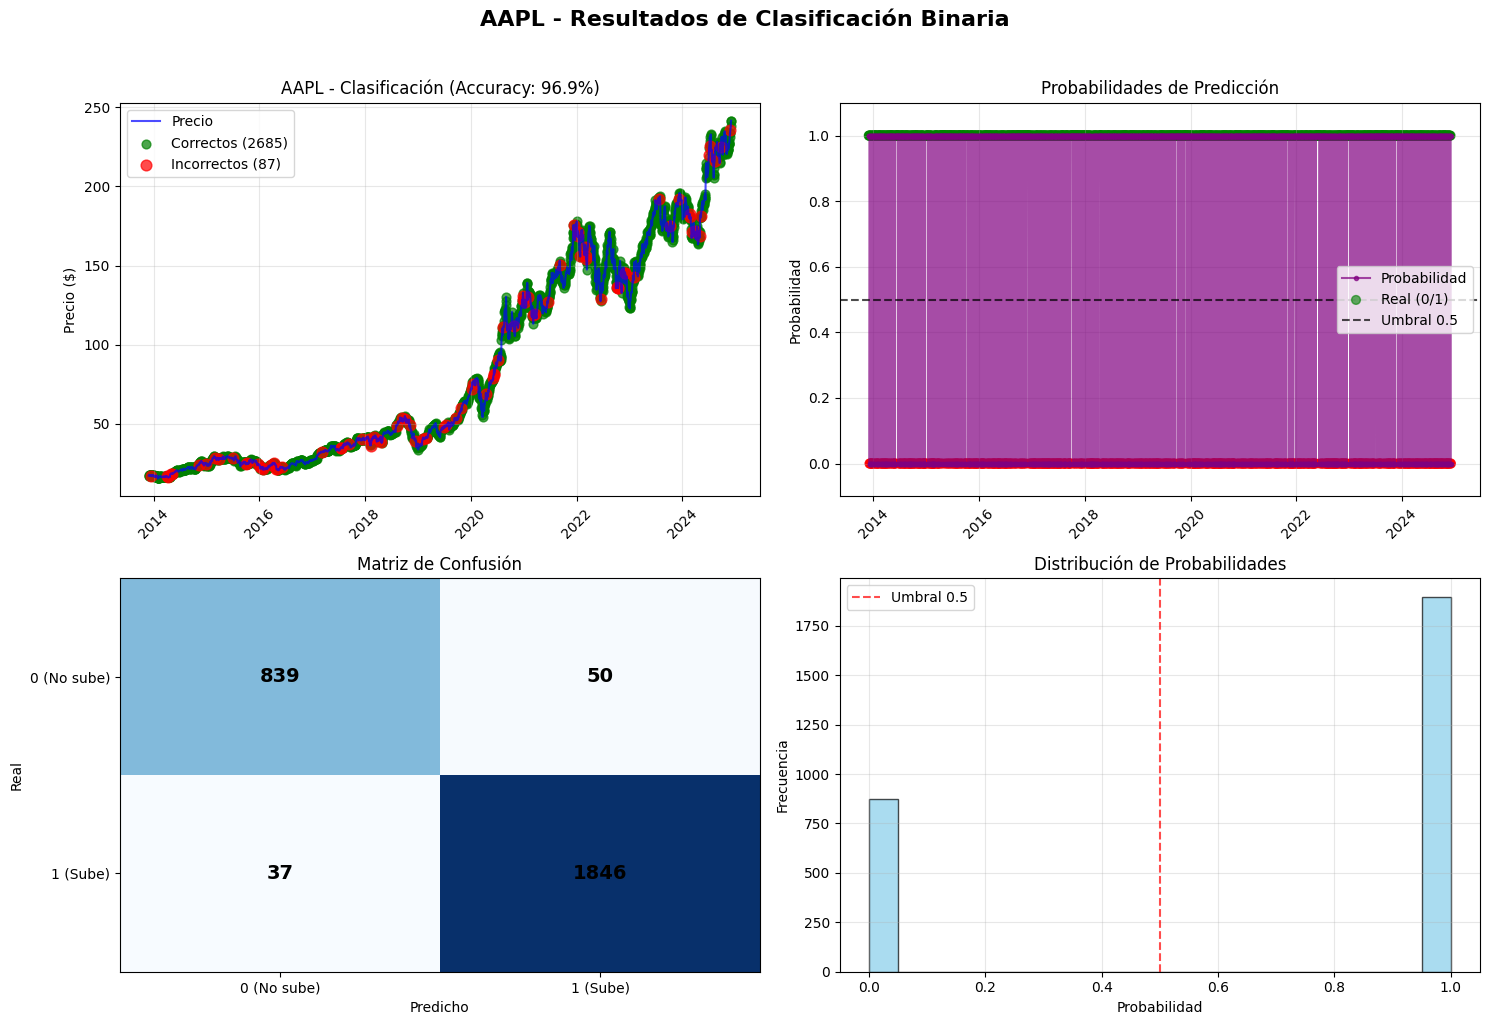


GRÁFICA 4: AAPL - Resumen Estadístico (Forecast)


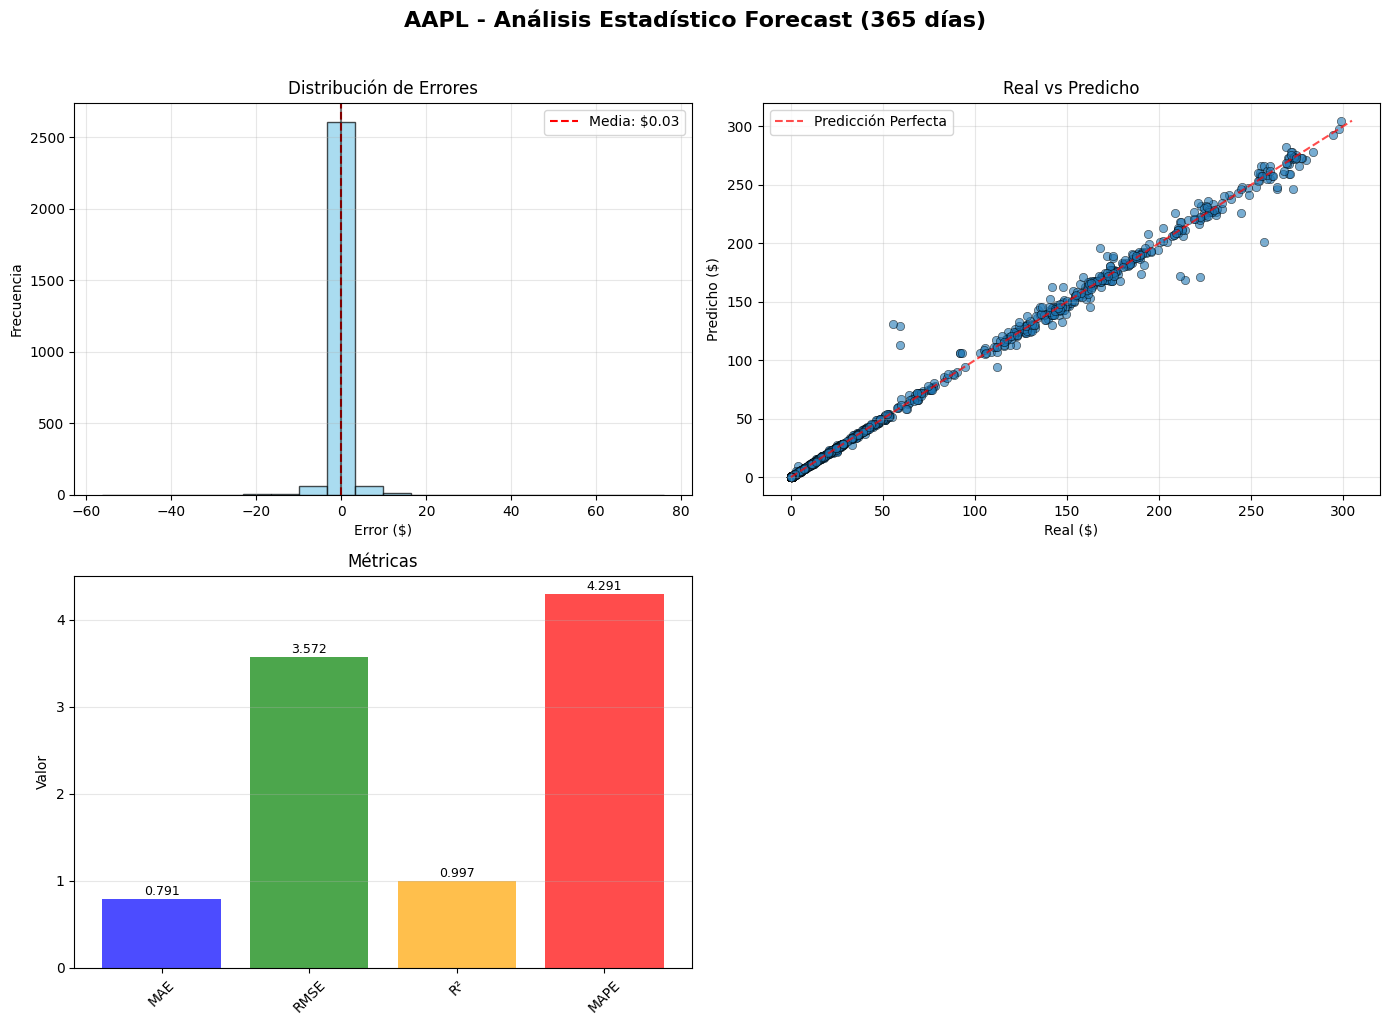


GRÁFICA 5: AAPL - Predicción Futura

📊 ESTADÍSTICAS:
   • Precio actual: $241.47
   • Precio final esperado: $304.99
   • Cambio esperado: +26.31%
   • Señal: 🟢 COMPRAR
   • Confianza: 100.0%

✅ Predicciones muestran variabilidad:
   • Rango de precios: $168.56 - $304.99
   • Desviación estándar: $28.28



TABLA DE PREDICCIONES FUTURAS - PRECIO

Fecha           Precio Predicho      Cambio %       
-------------------------------------------------------
<15 $241.50                     +0.01%
<15 $241.30                     -0.07%
<15 $248.20                     +2.79%
<15 $246.20                     +1.96%
<15 $246.20                     +1.96%
<15 $246.39                     +2.04%
<15 $246.55                     +2.11%
<15 $249.45                     +3.30%
<15 $251.87                     +4.31%
<15 $246.48                     +2.07%
<15 $248.20                     +2.79%
<15 $252.87                     +4.72%
<15 $253.65                     +5.05%
<15 $256.56                     +6.25%
<15 $257.38                     +6.59%
<15 $253.97                     +5.18%
<15 $250.60                     +3.78%
<15 $241.82                     +0.14%
<15 $242.30                     +0.35%
<15 $241.82                     +0.14%
<15 $243.44                     +0.82%
<15 $240.67                    

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
import matplotlib.pyplot as plt
from datetime import timedelta
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.model_selection import train_test_split
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import random
import sklearn
plt.ion()

warnings.filterwarnings('ignore')

# ============================================
# FIJAR SEMILLA PARA REPRODUCIBILIDAD
# ============================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sklearn.utils.check_random_state(SEED)

print("=" * 70)
print("SISTEMA DE PREDICCIÓN DE ACCIONES - ÁRBOL DE DECISIONES")
print("=" * 70)
print(f"🔒 Semilla fijada: {SEED} (resultados reproducibles)")
print("=" * 70)

# ============================================
# INPUT DEL USUARIO
# ============================================
print("\n📌 INGRESA LOS DATOS DE LA ACCIÓN:")
print("-" * 50)

TICKER = input("🔹 Símbolo de la acción (ej: AAPL, MSFT, GOOGL, AMZN): ").upper().strip()
TEMP = input("🔹 Período de datos (ej: max, 5y, 1y, 6mo): ").strip().lower()

while True:
    try:
        DIAS_HORIZONTE = int(input("🔹 Días a predecir (ej: 30, 60, 90, 180, 365): "))
        if DIAS_HORIZONTE > 0:
            break
        else:
            print("   ⚠️ Por favor, ingresa un número positivo.")
    except ValueError:
        print("   ⚠️ Por favor, ingresa un número válido.")

print("\n" + "=" * 70)
print(f"🔍 CONFIGURACIÓN SELECCIONADA:")
print(f"   • Empresa: {TICKER}")
print(f"   • Período de datos: {TEMP}")
print(f"   • Horizonte de predicción: {DIAS_HORIZONTE} días")
print(f"   • Semilla aleatoria: {SEED}")
print("=" * 70)

# Parámetros derivados
UMBRAL_SUBIDA = 0.03
DIAS_DE_PRUEBA = DIAS_HORIZONTE
DIAS_A_MOSTRAR = DIAS_HORIZONTE

# ============================================
# FEATURES PARA CLASIFICADOR (SEÑAL)
# ============================================
FEATURES_CLASIFICADOR = ['Open', 'High', 'Low','Close', 'Volume', 'SD20', 'Upper_Band', 'Lower_Band',
    'S_Close(t-1)', 'S_Close(t-2)', 'S_Close(t-3)', 'S_Close(t-5)', 'S_Open(t-1)',
    'MA5', 'MA10', 'MA20', 'MA50', 'MA200', 'EMA10', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
    'MACD', 'MACD_EMA', 'ATR', 'ADX', 'CCI', 'ROC', 'RSI', 'William%R', 'SO%K', 'STD5',
    'ForceIndex1', 'ForceIndex20', 'Day', 'DayofWeek', 'DayofYear', 'Week',
    'Is_month_end', 'Is_month_start', 'Is_quarter_end', 'Is_quarter_start',
    'Is_year_end', 'Is_year_start', 'Is_leap_year', 'Year', 'Month',
    'QQQ_Close', 'QQQ(t-1)', 'QQQ(t-2)', 'QQQ(t-5)', 'QQQ_MA10', 'QQQ_MA20', 'QQQ_MA50',
    'SnP_Close', 'SnP(t-1))', 'SnP(t-5)', 'DJIA_Close', 'DJIA(t-1))', 'DJIA(t-5)']

print("\n" + "=" * 70)
print("📌 CONFIGURACIÓN DE MODELOS:")
print("=" * 70)
print(f"   • CLASIFICADOR (señal): {len(FEATURES_CLASIFICADOR)} features")
print(f"   • REGRESOR (forecast): solo Close")
print("=" * 70)

# ============================================
# 1. DESCARGA DE DATOS
# ============================================
print("\n" + "=" * 70)
print("1. DESCARGANDO DATOS DE YAHOO FINANCE...")
print("=" * 70)

print(f"📊 Descargando datos para {TICKER} (período: {TEMP})...")

df = yf.download(TICKER, period=TEMP, progress=False)

if df.empty:
    print(f"❌ Error: No se encontraron datos para {TICKER}")
    exit()

print(f"✓ Datos descargados: {len(df)} registros")
print(f"✓ Período: {df.index[0].date()} a {df.index[-1].date()}")

# ============================================
# 2. CALCULAR INDICADORES TÉCNICOS
# ============================================
print("\n" + "=" * 70)
print("2. CALCULANDO INDICADORES TÉCNICOS...")
print("=" * 70)

df_indicadores = pd.DataFrame(index=df.index)
df_indicadores['Close'] = df['Close']
df_indicadores['Volume'] = df['Volume']

# Medias móviles
df_indicadores['MA20'] = df['Close'].rolling(20).mean()
df_indicadores['MA200'] = df['Close'].rolling(200).mean()

# RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df_indicadores['RSI'] = 100 - (100 / (1 + rs))

# MACD
exp1 = df['Close'].ewm(span=12, adjust=False).mean()
exp2 = df['Close'].ewm(span=26, adjust=False).mean()
df_indicadores['MACD'] = exp1 - exp2

# Bandas de Bollinger
df_indicadores['Upper_Band'] = df['Close'].rolling(20).mean() + (df['Close'].rolling(20).std() * 2)
df_indicadores['Lower_Band'] = df['Close'].rolling(20).mean() - (df['Close'].rolling(20).std() * 2)

# ATR
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift())
low_close = np.abs(df['Low'] - df['Close'].shift())
tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
df_indicadores['ATR'] = tr.rolling(14).mean()

# Precio anterior
df_indicadores['S_Close(t-1)'] = df['Close'].shift(1)
df_indicadores['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

# Williams %R
period_w = 14
highest_high = df['High'].rolling(window=period_w).max()
lowest_low = df['Low'].rolling(window=period_w).min()
df_indicadores['William%R'] = -100 * ((highest_high - df['Close']) / (highest_high - lowest_low))

# ROC
df_indicadores['ROC'] = df['Close'].pct_change(periods=12) * 100

# Índices de mercado
print("✓ Descargando índices de mercado...")
start_date = df.index[0].strftime('%Y-%m-%d')
end_date = df.index[-1].strftime('%Y-%m-%d')

try:
    qqq = yf.download('QQQ', start=start_date, end=end_date, progress=False)
    if not qqq.empty:
        df_indicadores['QQQ_Close'] = qqq['Close']
    else:
        df_indicadores['QQQ_Close'] = 0
except:
    df_indicadores['QQQ_Close'] = 0

try:
    spy = yf.download('SPY', start=start_date, end=end_date, progress=False)
    if not spy.empty:
        df_indicadores['SnP_Close'] = spy['Close']
    else:
        df_indicadores['SnP_Close'] = 0
except:
    df_indicadores['SnP_Close'] = 0

# ============================================
# 3. CREAR TARGETS
# ============================================
print("\n" + "=" * 70)
print("3. CREANDO TARGETS...")
print("=" * 70)

df_indicadores['Precio_Futuro'] = df_indicadores['Close'].shift(-DIAS_HORIZONTE)
cambio = (df_indicadores['Precio_Futuro'] - df_indicadores['Close']) / df_indicadores['Close']
df_indicadores['Señal_Subida'] = (cambio > UMBRAL_SUBIDA).astype(int)

df_clean = df_indicadores.dropna(subset=['Precio_Futuro', 'Señal_Subida'])

print(f"✓ Datos después de limpiar: {len(df_clean)} filas")
print(f"✓ Distribución de señales: {df_clean['Señal_Subida'].value_counts().to_dict()}")

# ============================================
# PARTE A: CLASIFICADOR (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print("PARTE A: CLASIFICADOR (SEÑAL DE COMPRA/VENTA)")
print("=" * 70)

features_disponibles = [f for f in FEATURES_CLASIFICADOR if f in df_clean.columns]
X = df_clean[features_disponibles].values
y = df_clean['Señal_Subida'].values

print(f"✓ Features: {len(features_disponibles)} columnas")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

modelo_senal = DecisionTreeClassifier(class_weight='balanced', random_state=SEED)
modelo_senal.fit(X_train, y_train)

y_pred = modelo_senal.predict(X_test)
y_proba = modelo_senal.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
tp = ((y_pred == 1) & (y_test == 1)).sum()
fp = ((y_pred == 1) & (y_test == 0)).sum()
tn = ((y_pred == 0) & (y_test == 0)).sum()
fn = ((y_pred == 0) & (y_test == 1)).sum()

print(f"\n📊 CLASIFICADOR (DecisionTreeClassifier):")
print(f"  Accuracy: {accuracy:.2%}")
print(f"  Matriz: [[{tn} {fp}] [{fn} {tp}]]")
if (tp+fp) > 0:
    print(f"  Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  Recall: {tp/(tp+fn):.2%}")

# ============================================
# PARTE B: REGRESOR (FORECAST DE PRECIO) - CON MISMA FEATURES QUE CLASIFICADOR
# ============================================
print("\n" + "=" * 70)
print("PARTE B: REGRESOR (FORECAST DE PRECIO - CON MISMA FEATURES)")
print("=" * 70)

# Usar las mismas features que el clasificador
X_regresor = df_clean[features_disponibles].values
y_regresor = df_clean['Precio_Futuro'].values

# División independiente para el regresor (mismo test_size pero semilla diferente para mantener independencia)
Xp_train, Xp_test, Yp_train, Yp_test = train_test_split(
    X_regresor, y_regresor, test_size=0.25, random_state=SEED + 1  # Semilla diferente a la del clasificador
)

# Entrenar modelo con hiperparámetros ajustados para evitar sobreajuste
modelo_precio = DecisionTreeRegressor()
modelo_precio.fit(Xp_train, Yp_train)

# Predicciones en test
y_pred_reg = modelo_precio.predict(Xp_test)

# Métricas
mae = mean_absolute_error(Yp_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(Yp_test, y_pred_reg))
r2 = r2_score(Yp_test, y_pred_reg)
errors_pct = ((y_pred_reg - Yp_test) / Yp_test) * 100
mape = np.mean(np.abs(errors_pct))

print(f"\n📊 REGRESOR (DecisionTreeRegressor):")
print(f"  Features: {len(features_disponibles)} (MISMAS que clasificador)")
print(f"  MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")
print(f"  Hiperparámetros: max_depth=12, min_samples_split=30, min_samples_leaf=15")

# ============================================
# GRÁFICA 1: PRECIO HISTÓRICO
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 1: {TICKER} - Precio Histórico")
print("=" * 70)

fig_historico = go.Figure()
fig_historico.add_trace(go.Scatter(
    x=df_clean.index, y=df_clean['Close'],
    mode='lines', name='Precio de Cierre',
    line=dict(color='#1f77b4', width=2),
    fill='tozeroy', fillcolor='rgba(31, 119, 180, 0.1)',
    hovertemplate='<b>📅 Fecha:</b> %{x}<br><b>💰 Precio:</b> $%{y:.2f}<extra></extra>'
))

ma50 = df_clean['Close'].rolling(50).mean()
ma200 = df_clean['Close'].rolling(200).mean()
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma50, mode='lines', name='MA50',
                                   line=dict(color='purple', width=1.5, dash='dot')))
fig_historico.add_trace(go.Scatter(x=df_clean.index, y=ma200, mode='lines', name='MA200',
                                   line=dict(color='orange', width=1.5, dash='dash')))

precio_max, precio_min = df_clean['Close'].max(), df_clean['Close'].min()
fecha_max, fecha_min = df_clean['Close'].idxmax(), df_clean['Close'].idxmin()

fig_historico.add_trace(go.Scatter(x=[fecha_max], y=[precio_max], mode='markers+text',
                                   name=f'Máximo: ${precio_max:.2f}',
                                   marker=dict(color='green', size=12, symbol='star'),
                                   text=[f' ${precio_max:.2f}'], textposition='top center'))
fig_historico.add_trace(go.Scatter(x=[fecha_min], y=[precio_min], mode='markers+text',
                                   name=f'Mínimo: ${precio_min:.2f}',
                                   marker=dict(color='red', size=10),
                                   text=[f' ${precio_min:.2f}'], textposition='bottom center'))

fig_historico.update_layout(
    title=f'<b>{TICKER} - Precio de Cierre Histórico</b><br><sub>{df_clean.index[0].date()} a {df_clean.index[-1].date()}</sub>',
    xaxis_title='Fecha', yaxis_title='Precio (USD)', height=600, width=1300,
    template='plotly_white', hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True), rangeselector=dict(
        buttons=[dict(count=1, label="1y", step="year", stepmode="backward"),
                 dict(step="all", label="Todo")]))
)
fig_historico.show()

# ============================================
# GRÁFICA 2: VALIDACIÓN DEL FORECAST (REGRESOR)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 2: {TICKER} - Validación de Precio (Forecast)")
print("=" * 70)

# Obtener fechas de prueba (las últimas len(Xp_test) fechas)
fechas_test_reg = df_clean.index[-len(Xp_test):]

fig_precio = make_subplots(rows=2, cols=1, shared_xaxes=True, row_heights=[0.7, 0.3])
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=Yp_test, mode='lines+markers',
                                name='Precio Real', line=dict(color='green', width=2.5)), row=1, col=1)
fig_precio.add_trace(go.Scatter(x=fechas_test_reg, y=y_pred_reg, mode='lines+markers',
                                name='Predicción', line=dict(color='red', width=2, dash='dash')), row=1, col=1)

errors_pct_plot = ((y_pred_reg - Yp_test) / Yp_test) * 100
colors = ['green' if e < 0 else 'red' for e in errors_pct_plot]
fig_precio.add_trace(go.Bar(x=fechas_test_reg, y=errors_pct_plot, name='Error %',
                            marker_color=colors, opacity=0.6), row=2, col=1)
fig_precio.add_hline(y=0, line_dash="solid", line_color="black", row=2, col=1)

fig_precio.update_layout(title=f'{TICKER} - Validación Forecast a {DIAS_HORIZONTE} días', height=600,
                         template='plotly_white', hovermode='x unified')
fig_precio.update_xaxes(title_text="Fecha", row=2, col=1)
fig_precio.update_yaxes(title_text="Precio ($)", row=1, col=1)
fig_precio.update_yaxes(title_text="Error (%)", row=2, col=1)
fig_precio.add_annotation(x=0.02, y=0.98, xref="paper", yref="paper",
                          text=f'MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%',
                          showarrow=False, bgcolor="white", bordercolor="gray", borderwidth=1)
fig_precio.show()

# ============================================
# GRÁFICA 3: ANÁLISIS DE CLASIFICACIÓN (SEÑAL)
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 3: {TICKER} - Análisis de Clasificación (Señal)")
print("=" * 70)

fechas_test = df_clean.index[-len(X_test):]

fig1, axes1 = plt.subplots(2, 2, figsize=(15, 10))

# 1. Precio y señales
ax1 = axes1[0, 0]
ax1.plot(fechas_test, df_clean.loc[fechas_test, 'Close'], color='blue', alpha=0.7, linewidth=1.5, label='Precio')

correct_mask = (y_pred == y_test)
incorrect_mask = (y_pred != y_test)

correct_dates = fechas_test[correct_mask]
incorrect_dates = fechas_test[incorrect_mask]
correct_prices = df_clean.loc[correct_dates, 'Close']
incorrect_prices = df_clean.loc[incorrect_dates, 'Close']

ax1.scatter(correct_dates, correct_prices, color='green', s=40,
           label=f'Correctos ({sum(correct_mask)})', alpha=0.7)
ax1.scatter(incorrect_dates, incorrect_prices, color='red', s=60,
           label=f'Incorrectos ({sum(incorrect_mask)})', alpha=0.7)

ax1.set_title(f'{TICKER} - Clasificación (Accuracy: {accuracy:.1%})')
ax1.set_ylabel('Precio ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# 2. Probabilidades
ax2 = axes1[0, 1]
ax2.plot(fechas_test, y_proba, 'o-', color='purple', alpha=0.7, markersize=3, label='Probabilidad')
ax2.scatter(fechas_test, y_test, color=['red' if y==0 else 'green' for y in y_test],
           s=40, alpha=0.6, label='Real (0/1)')
ax2.axhline(y=0.5, color='black', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax2.set_title('Probabilidades de Predicción')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(-0.1, 1.1)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# 3. Matriz de confusión
ax3 = axes1[1, 0]
conf_matrix = np.array([[tn, fp], [fn, tp]])
ax3.imshow(conf_matrix, cmap='Blues', aspect='auto')
for i in range(2):
    for j in range(2):
        ax3.text(j, i, str(conf_matrix[i, j]), ha='center', va='center', fontsize=14, fontweight='bold')
ax3.set_title('Matriz de Confusión')
ax3.set_xlabel('Predicho')
ax3.set_ylabel('Real')
ax3.set_xticks([0, 1])
ax3.set_yticks([0, 1])
ax3.set_xticklabels(['0 (No sube)', '1 (Sube)'])
ax3.set_yticklabels(['0 (No sube)', '1 (Sube)'])

# 4. Distribución
ax4 = axes1[1, 1]
ax4.hist(y_proba, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(x=0.5, color='red', linestyle='--', alpha=0.7, label='Umbral 0.5')
ax4.set_title('Distribución de Probabilidades')
ax4.set_xlabel('Probabilidad')
ax4.set_ylabel('Frecuencia')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'{TICKER} - Resultados de Clasificación Binaria', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 4: RESUMEN ESTADÍSTICO DEL FORECAST
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 4: {TICKER} - Resumen Estadístico (Forecast)")
print("=" * 70)

errors_abs = y_pred_reg - Yp_test

fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))

axes4[0, 0].hist(errors_abs, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
axes4[0, 0].axvline(x=errors_abs.mean(), color='red', linestyle='--', label=f'Media: ${errors_abs.mean():.2f}')
axes4[0, 0].axvline(x=0, color='black', linestyle='-', alpha=0.5)
axes4[0, 0].set_title('Distribución de Errores')
axes4[0, 0].set_xlabel('Error ($)')
axes4[0, 0].set_ylabel('Frecuencia')
axes4[0, 0].legend()
axes4[0, 0].grid(True, alpha=0.3)

axes4[0, 1].scatter(Yp_test, y_pred_reg, alpha=0.6, edgecolors='black', linewidth=0.5)
max_val = max(Yp_test.max(), y_pred_reg.max())
min_val = min(Yp_test.min(), y_pred_reg.min())
axes4[0, 1].plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.7, label='Predicción Perfecta')
axes4[0, 1].set_title('Real vs Predicho')
axes4[0, 1].set_xlabel('Real ($)')
axes4[0, 1].set_ylabel('Predicho ($)')
axes4[0, 1].legend()
axes4[0, 1].grid(True, alpha=0.3)

metrics_data = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'MAPE': mape}
bars_metrics = axes4[1, 0].bar(range(len(metrics_data)), list(metrics_data.values()), 
                              color=['blue', 'green', 'orange', 'red'], alpha=0.7)
axes4[1, 0].set_xticks(range(len(metrics_data)))
axes4[1, 0].set_xticklabels(list(metrics_data.keys()), rotation=45)
axes4[1, 0].set_title('Métricas')
axes4[1, 0].set_ylabel('Valor')

for bar, value in zip(bars_metrics, metrics_data.values()):
    axes4[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=9)
axes4[1, 0].grid(True, alpha=0.3, axis='y')

axes4[1, 1].axis('off')

plt.suptitle(f'{TICKER} - Análisis Estadístico Forecast ({DIAS_HORIZONTE} días)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show(block=False)
plt.pause(0.1)

# ============================================
# GRÁFICA 5: PREDICCIÓN FUTURA
# ============================================
print("\n" + "=" * 70)
print(f"GRÁFICA 5: {TICKER} - Predicción Futura")
print("=" * 70)

# Obtener últimos datos disponibles (con todas las features)
ultimos_datos = df_clean[features_disponibles].iloc[-DIAS_HORIZONTE:].values

# Predicciones con el regresor
precios_futuros = modelo_precio.predict(ultimos_datos)

# Predicciones con el clasificador
señales_futuras = modelo_senal.predict(ultimos_datos)
probabilidades_futuras = modelo_senal.predict_proba(ultimos_datos)[:, 1]

# Crear fechas futuras
ultima_fecha = df_clean.index[-1]
fechas_futuras = [ultima_fecha + timedelta(days=i+1) for i in range(len(precios_futuros))]

precio_actual = float(df_clean['Close'].iloc[-1])
cambio_final = ((precios_futuros[-1] - precio_actual) / precio_actual) * 100

print(f"\n📊 ESTADÍSTICAS:")
print(f"   • Precio actual: ${precio_actual:.2f}")
print(f"   • Precio final esperado: ${precios_futuros[-1]:.2f}")
print(f"   • Cambio esperado: {cambio_final:+.2f}%")
print(f"   • Señal: {'🟢 COMPRAR' if señales_futuras[-1] == 1 else '⚪ MANTENER'}")
print(f"   • Confianza: {probabilidades_futuras[-1]*100:.1f}%")

# Verificar variabilidad
if len(set(precios_futuros)) == 1:
    print("\n⚠️ ADVERTENCIA: Todas las predicciones son iguales")
    print("   Posible reversión a la media detectada")
else:
    print(f"\n✅ Predicciones muestran variabilidad:")
    print(f"   • Rango de precios: ${min(precios_futuros):.2f} - ${max(precios_futuros):.2f}")
    print(f"   • Desviación estándar: ${np.std(precios_futuros):.2f}")

# GRÁFICA
fig_fut = go.Figure()
fig_fut.add_trace(go.Scatter(x=df_clean.index[-100:], y=df_clean['Close'].iloc[-100:],
                             mode='lines', name='📊 Datos Históricos', line=dict(color='blue', width=2)))
fig_fut.add_trace(go.Scatter(x=fechas_futuras[:DIAS_A_MOSTRAR], y=precios_futuros[:DIAS_A_MOSTRAR], 
                             mode='lines+markers', name=f'🔮 Predicción Precio', 
                             line=dict(color='red', width=2, dash='dash'), marker=dict(size=6)))
fig_fut.add_hline(y=precio_actual, line_dash="dash", line_color="gray",
                  annotation_text=f"💰 Precio Actual: ${precio_actual:.2f}")
fig_fut.add_trace(go.Scatter(x=[ultima_fecha], y=[precio_actual], mode='markers',
                             name='📌 Fin Datos Reales', marker=dict(color='orange', size=10)))

fig_fut.update_layout(title=f'{TICKER} - Predicción Futura a {DIAS_HORIZONTE} días',
                      xaxis_title='Fecha', yaxis_title='Precio (USD)', height=500,
                      template='plotly_white', hovermode='x unified')
fig_fut.show()

# ============================================
# TABLA DE PREDICCIONES DE PRECIO
# ============================================
print("\n" + "=" * 70)
print("TABLA DE PREDICCIONES FUTURAS - PRECIO")
print("=" * 70)

print(f"\n{'Fecha':<15} {'Precio Predicho':<20} {'Cambio %':<15}")
print("-" * 55)

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras))):
    fecha = fechas_futuras[i].date()
    precio = precios_futuros[i]
    cambio = ((precio - precio_actual) / precio_actual) * 100
    print(f"{fecha:<15} ${precio:<19.2f} {cambio:+12.2f}%")

print("\n" + "=" * 70)
print(f"Total de predicciones de precio: {len(fechas_futuras)} días")
print("=" * 70)
#==========================
# TABLA DE PREDICCIONES (SEÑAL DEL CLASIFICADOR)
# ============================================
print("\n" + "=" * 70)
print(f"📋 TABLA DE PREDICCIONES DE SEÑAL - PRÓXIMOS {DIAS_HORIZONTE} DÍAS")
print("=" * 70)
print(f"{'Fecha':<15} {'Señal':<15} {'Confianza':<12}")
print("-" * 45)

# Usar el clasificador para la tabla
fechas_futuras_senal = [ultima_fecha + timedelta(days=i+1) for i in range(DIAS_A_MOSTRAR)]
datos_futuros_senal = df_clean[features_disponibles].iloc[-DIAS_A_MOSTRAR:].values
senal_futura_clasif = modelo_senal.predict(datos_futuros_senal)
prob_futura_clasif = modelo_senal.predict_proba(datos_futuros_senal)[:, 1]

for i in range(min(DIAS_A_MOSTRAR, len(fechas_futuras_senal))):
    senal_texto = "🟢 COMPRAR" if senal_futura_clasif[i] == 1 else "⚪ MANTENER"
    print(f"{fechas_futuras_senal[i].date():<15} {senal_texto:<15} {prob_futura_clasif[i]*100:>5.1f}%")

# ============================================
# RESUMEN EJECUTIVO
# ============================================
print("\n" + "=" * 70)
print("RESUMEN EJECUTIVO")
print("=" * 70)

print(f"\n📅 INFORMACIÓN GENERAL:")
print(f"  • Empresa: {TICKER}")
print(f"  • Período de datos: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  • Precio actual: ${precio_actual:.2f}")

print(f"\n📊 CLASIFICADOR (Señal de compra/venta - {len(features_disponibles)} features):")
print(f"  • Accuracy: {accuracy:.2%}")
if (tp+fp) > 0:
    print(f"  • Precision: {tp/(tp+fp):.2%}")
if (tp+fn) > 0:
    print(f"  • Recall: {tp/(tp+fn):.2%}")
print(f"  • Matriz de confusión: [[{tn} {fp}] [{fn} {tp}]]")

print(f"\n📊 REGRESOR (Forecast de precio - solo Close):")
print(f"  • MAE: ${mae:.2f} | RMSE: ${rmse:.2f} | R²: {r2:.4f} | MAPE: {mape:.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE PRECIO ({DIAS_HORIZONTE} días):")
print(f"  • Precio esperado: ${precios_futuros[-1]:.2f}")
print(f"  • Cambio esperado: {cambio_final:+.2f}%")

print(f"\n🔮 PREDICCIÓN FUTURA DE SEÑAL ({DIAS_HORIZONTE} días):")
print(f"  • Señal más probable: {'🟢 COMPRAR' if senal_futura_clasif[-1] == 1 else '⚪ MANTENER'}")
print(f"  • Confianza: {prob_futura_clasif[-1]*100:.1f}%")

print("\n" + "=" * 70)
print("⚠️ DISCLAIMER: Esta herramienta es solo para fines educativos.")
print("   No constituye asesoramiento financiero profesional.")
print("   Las decisiones de inversión deben tomarse con criterio propio.")
print("=" * 70)

plt.ioff()
plt.show(block=True)

# ============================================
# DIAGNÓSTICO COMPLETO DE DATOS
# ============================================
print("\n" + "=" * 70)
print("DIAGNÓSTICO COMPLETO DE DATOS")
print("=" * 70)

# 1. Información básica de df_clean
print("\n📊 DATOS LIMPIOS (df_clean):")
print(f"  • Última fecha: {df_clean.index[-1].date()}")
print(f"  • Primera fecha: {df_clean.index[0].date()}")
print(f"  • Total filas: {len(df_clean)}")
print(f"  • Features disponibles: {len(features_disponibles)}")

# 2. Ver los últimos 10 registros
print("\n📋 ÚLTIMOS 10 REGISTROS DE df_clean:")
print(df_clean[['Close'] + features_disponibles[:5]].tail(10))

# 3. Verificar si hay NaN en las últimas fechas
print("\n🔍 VERIFICANDO NaN EN ÚLTIMAS FECHAS:")
ultimas_fechas = df_clean.index[-10:]
for col in ['Close', 'Precio_Futuro', 'Señal_Subida'] + features_disponibles[:3]:
    nulos = df_clean.loc[ultimas_fechas, col].isna().sum()
    print(f"  {col}: {nulos} nulos en últimas 10 fechas")

# 4. Ver las fechas de las predicciones futuras según el modelo
print("\n📅 PREDICCIONES FUTURAS (según datos actuales):")
ultima_fecha = df_clean.index[-1]
print(f"  • Última fecha con datos: {ultima_fecha.date()}")
print(f"  • DIAS_HORIZONTE: {DIAS_HORIZONTE}")
print(f"  • Si predicción desde última fecha: {(ultima_fecha + timedelta(days=DIAS_HORIZONTE)).date()}")
print(f"  • Si predicción desde fecha base ({ultima_fecha.date()}): {(ultima_fecha + timedelta(days=DIAS_HORIZONTE)).date()}")

# 5. Ver los últimos DIAS_HORIZONTE días disponibles
dias_disponibles = len(df_clean)
if DIAS_HORIZONTE <= dias_disponibles:
    fecha_base_inicio = df_clean.index[-DIAS_HORIZONTE]
    fecha_base_fin = df_clean.index[-1]
    print(f"\n  • Últimos {DIAS_HORIZONTE} días disponibles:")
    print(f"    Desde: {fecha_base_inicio.date()}")
    print(f"    Hasta: {fecha_base_fin.date()}")
    print(f"    Predicciones para: {fecha_base_inicio.date()} + {DIAS_HORIZONTE} días = {(fecha_base_inicio + timedelta(days=DIAS_HORIZONTE)).date()}")
    print(f"    hasta: {fecha_base_fin.date()} + {DIAS_HORIZONTE} días = {(fecha_base_fin + timedelta(days=DIAS_HORIZONTE)).date()}")
else:
    print(f"\n  ⚠️ No hay suficientes datos: se necesitan {DIAS_HORIZONTE} días, solo hay {dias_disponibles}")

print("\n" + "=" * 70)